In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d, griddata
import matplotlib.pyplot as plt
import glob
import matplotlib.dates as mdates
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import time
import gsw
from datetime import datetime
import geopandas as gpd
from matplotlib.dates import DateFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
from pathlib import Path

import cartopy
import cartopy.crs as ccrs

# custom functions 
from utils import *

In [ ]:
import numpy as np
import cartopy.feature as cfeature
from shapely.geometry import box, LineString, MultiLineString, GeometryCollection

def coastline_points(region, scale="10m"):
    """
    Extracts the coastline coordinates from the Natural Earth database using cartopy
    
    Returns the lat and lon coordinates
    """

    lon_min, lon_max, lat_min, lat_max = region
    clip_box = box(lon_min, lat_min, lon_max, lat_max)

    coast = cfeature.NaturalEarthFeature("physical", "coastline", scale)

    lon_all = []
    lat_all = []

    for geom in coast.geometries():
        clipped = geom.intersection(clip_box)

        if clipped.is_empty:
            continue

        # Handle the different geometry types that can come back
        geoms = []
        if clipped.geom_type == "LineString":
            geoms = [clipped]
        elif clipped.geom_type == "MultiLineString":
            geoms = list(clipped.geoms)
        elif clipped.geom_type == "GeometryCollection":
            geoms = [g for g in clipped.geoms if g.geom_type == "LineString"]

        for g in geoms:
            coords = np.asarray(g.coords)
            lon_all.append(coords[:, 0])
            lat_all.append(coords[:, 1])

    if not lon_all:
        return np.array([]), np.array([])

    return np.concatenate(lon_all), np.concatenate(lat_all)

In [ ]:
# set bounding box, format:
# region = [lon_min, lon_max, lat_min, lat_max]
region = [-3, 2, 2, 7]

# extract lat, lon
coast_lon, coast_lat = coastline_points(region, scale="10m")

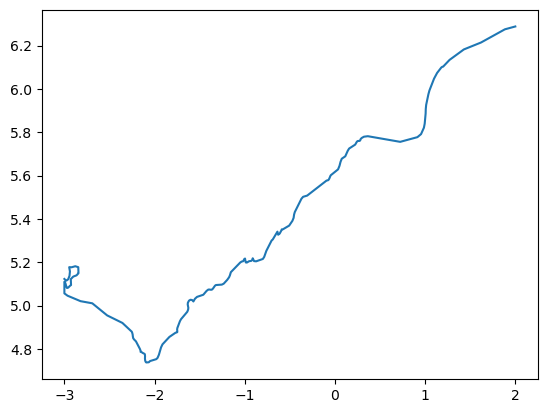

In [11]:
plt.plot(coast_lon, coast_lat)

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import griddata
from scipy.stats import linregress

# assumes you already have:
# - haversine_np
# - do_lines_intersect
# - line_intersection
# - coastline_points(region, ...)  -> returns coast_lon, coast_lat


def calc_cross_shore_distance(datasets, coast_lon, coast_lat):
    """
    Compute along-transect cross-shore distance for each profile station.

    Returns only geometry/distance outputs.
    """
    # ----------------------------
    # 1. Extract profile coordinates
    # ----------------------------
    coords = [(ds.lat[0].values.item(), ds.lon[0].values.item()) for ds in datasets]
    profile_lats, profile_lons = zip(*coords)
    profile_lats = np.asarray(profile_lats, dtype=float)
    profile_lons = np.asarray(profile_lons, dtype=float)

    if len(profile_lats) < 2:
        raise ValueError("Need at least two profiles to define a transect.")

    # ----------------------------
    # 2. Best-fit transect line in lon-lat space
    # ----------------------------
    slope, intercept, _, _, _ = linregress(profile_lons, profile_lats)

    transect_lons = np.linspace(np.min(profile_lons) - 0.1, np.max(profile_lons) + 0.1, 400)
    transect_lats = slope * transect_lons + intercept

    # ----------------------------
    # 3. Find all coastline intersections
    # ----------------------------
    intersections = []

    for i in range(len(transect_lons) - 1):
        p1 = (transect_lons[i], transect_lats[i])
        p2 = (transect_lons[i + 1], transect_lats[i + 1])

        for j in range(len(coast_lon) - 1):
            q1 = (coast_lon[j], coast_lat[j])
            q2 = (coast_lon[j + 1], coast_lat[j + 1])

            if do_lines_intersect(p1, p2, q1, q2):
                try:
                    inter_lon, inter_lat = line_intersection(p1, p2, q1, q2)
                    if np.isfinite(inter_lon) and np.isfinite(inter_lat):
                        intersections.append((inter_lon, inter_lat))
                except Exception:
                    pass

    if len(intersections) == 0:
        raise ValueError("No intersection found between transect line and coastline.")

    intersections = np.asarray(intersections)

    # Choose the coastline intersection closest to the profile centroid
    centroid_lon = np.mean(profile_lons)
    centroid_lat = np.mean(profile_lats)
    d2 = (intersections[:, 0] - centroid_lon) ** 2 + (intersections[:, 1] - centroid_lat) ** 2
    best_idx = np.argmin(d2)
    intersect_lon, intersect_lat = intersections[best_idx]

    # ----------------------------
    # 4. Build unit transect direction vector in km
    # ----------------------------
    ref1 = (transect_lats[0], transect_lons[0])
    ref2 = (transect_lats[-1], transect_lons[-1])

    dx = haversine_np((ref1[0], ref1[1]), (ref1[0], ref2[1]))
    if ref2[1] < ref1[1]:
        dx *= -1

    dy = haversine_np((ref1[0], ref1[1]), (ref2[0], ref1[1]))
    if ref2[0] < ref1[0]:
        dy *= -1

    transect_vec = np.array([dx, dy], dtype=float)
    norm = np.linalg.norm(transect_vec)
    if norm == 0:
        raise ValueError("Transect direction vector has zero length.")
    transect_vec /= norm

    # ----------------------------
    # 5. Project each profile onto the transect
    # ----------------------------
    original_distance = []
    for lat, lon in zip(profile_lats, profile_lons):
        dlon = haversine_np((intersect_lat, intersect_lon), (intersect_lat, lon))
        if lon < intersect_lon:
            dlon *= -1

        dlat = haversine_np((intersect_lat, intersect_lon), (lat, intersect_lon))
        if lat < intersect_lat:
            dlat *= -1

        vec = np.array([dlon, dlat], dtype=float)
        original_distance.append(np.dot(vec, transect_vec))

    original_distance = np.asarray(original_distance)

    # ----------------------------
    # 6. Sort nearshore -> offshore
    # ----------------------------
    sort_idx = np.argsort(original_distance)
    sorted_distance = original_distance[sort_idx]

    if np.abs(sorted_distance[-1]) < np.abs(sorted_distance[0]):
        sort_idx = sort_idx[::-1]

    profile_lats = profile_lats[sort_idx]
    profile_lons = profile_lons[sort_idx]
    distance = original_distance[sort_idx]

    coords = [coords[i] for i in sort_idx]
    datasets = [datasets[i] for i in sort_idx]

    # Optional: make coast = 0-ish orientation cleaner
    if distance[0] < 0 and distance[-1] < 0:
        distance = -distance

    return {
        "profile_lats": profile_lats,
        "profile_lons": profile_lons,
        "distance": distance,
        "transect_lons": transect_lons,
        "transect_lats": transect_lats,
        "intersect_lon": intersect_lon,
        "intersect_lat": intersect_lat,
        "coords": coords,
        "datasets": datasets,
    }


In [ ]:
def extract_transect_bathymetry(profile_lons, profile_lats, region, bathy_ds=None, bathy_file=None,
                                depth_jump_threshold=150):
    """
    Sample bathymetry at the profile locations.

    Returns a 1D array of depths aligned with profile_lons/profile_lats.
    """
    close_ds = False

    if bathy_ds is None:
        if bathy_file is not None:
            bathy_ds = xr.open_dataset(bathy_file)
            close_ds = True
        else:
            bathy_ds = xr.open_dataset("GIS_data/gebco_2023_n12.0_s-12.0_w-21.0_e16.0.nc")
            close_ds = True

    try:
        lon_min, lon_max = min(region[0], region[1]), max(region[0], region[1])
        lat_min, lat_max = min(region[2], region[3]), max(region[2], region[3])

        if bathy_ds.lat.values[0] < bathy_ds.lat.values[-1]:
            lat_slice = slice(lat_min, lat_max)
        else:
            lat_slice = slice(lat_max, lat_min)

        bathy_ds = bathy_ds.sel(lon=slice(lon_min, lon_max), lat=lat_slice)

        b_lats = bathy_ds["lat"].values
        b_lons = bathy_ds["lon"].values
        b_depth_grid = bathy_ds["elevation"].values

        lon2d, lat2d = np.meshgrid(b_lons, b_lats)
        b_lons_flat = lon2d.ravel()
        b_lats_flat = lat2d.ravel()
        b_depths_flat = b_depth_grid.ravel()

        valid_mask = np.isfinite(b_depths_flat)
        b_lons_flat = b_lons_flat[valid_mask]
        b_lats_flat = b_lats_flat[valid_mask]
        b_depths_flat = b_depths_flat[valid_mask]

        transect_depths = griddata(
            (b_lons_flat, b_lats_flat),
            b_depths_flat,
            (profile_lons, profile_lats),
            method="nearest",
        )

        # Optional jump filtering
        if transect_depths is not None and len(transect_depths) > 1:
            valid_depth_mask = np.isfinite(transect_depths)

            if np.sum(valid_depth_mask) > 1:
                valid_depths = transect_depths[valid_depth_mask]
                depth_changes = np.abs(np.diff(valid_depths))
                jump_index = np.where(depth_changes > depth_jump_threshold)[0]

                if jump_index.size > 0:
                    first_jump_valid = jump_index[0] + 1
                    valid_positions = np.where(valid_depth_mask)[0]
                    first_jump_full = valid_positions[first_jump_valid]
                    transect_depths[first_jump_full:] = np.nan

        return transect_depths

    finally:
        if close_ds:
            bathy_ds.close()

In [ ]:
def build_coastal_section(datasets, region, coast_lon=None, coast_lat=None,
                          use_bathy=False, bathy_ds=None, bathy_file=None,
                          depth_jump_threshold=150):
    """
    Master wrapper for coastal-section plotting.
    """
    if coast_lon is None or coast_lat is None:
        coast_lon, coast_lat = coastline_points(region)

    out = calc_cross_shore_distance(datasets, coast_lon, coast_lat)

    if use_bathy:
        transect_depths = extract_transect_bathymetry(
            out["profile_lons"],
            out["profile_lats"],
            region=region,
            bathy_ds=bathy_ds,
            bathy_file=bathy_file,
            depth_jump_threshold=depth_jump_threshold,
        )
    else:
        transect_depths = None

    out["transect_depths"] = transect_depths
    return out

In [43]:
out = calc_cross_shore_distance(datasets, coast_lon, coast_lat)

In [44]:
out

{'profile_lats': array([5.41310687, 5.41181885, 5.41050027, 5.40920265, 5.4079168 ,
        5.40675418, 5.40551811, 5.40417555, 5.40283328, 5.40145367,
        5.39959742, 5.3984105 , 5.39714059, 5.39582263, 5.39442473,
        5.39300475, 5.39157911, 5.39022209, 5.38892038, 5.387574  ,
        5.38615814, 5.38481223, 5.38342705, 5.38198093, 5.38051753,
        5.37901282, 5.37755056, 5.37605936, 5.3745825 , 5.37304182,
        5.37143757, 5.36985327, 5.36834623, 5.36683499, 5.36534207,
        5.36362623, 5.36198301, 5.36029377, 5.35855264, 5.35676083,
        5.35493384, 5.35314513, 5.351341  , 5.3494752 , 5.34766865,
        5.34596282, 5.3441426 , 5.34238648, 5.3405832 , 5.33883249,
        5.33692297, 5.3349735 , 5.33293266, 5.33095909, 5.32899189,
        5.32697838, 5.32498357, 5.32282486, 5.32059808, 5.31590652,
        5.31351395, 5.31130225, 5.30910877, 5.30678936, 5.30439051,
        5.30173703, 5.29901009, 5.29642863, 5.29391595, 5.29102918,
        5.288147  , 5.28487782, 

In [23]:
profile_lats = test['profile_lats']
profile_lons = test['profile_lons']
int_lon = test['intersect_lon']
int_lat = test['intersect_lat']
tran_lons = test['transect_lons']
tran_lats = test['transect_lats']

(4.5, 6.0)

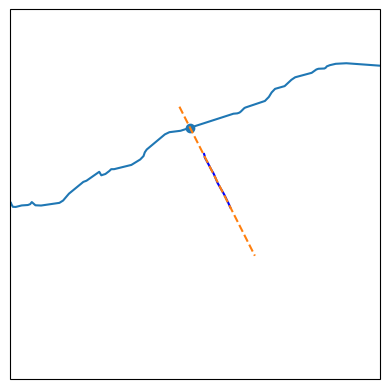

In [40]:
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

ax.plot(profile_lons, profile_lats, color="b")
ax.plot(coast_lon, coast_lat)
ax.plot(tran_lons, tran_lats, linestyle="--")
ax.scatter(int_lon, int_lat)

ax.set_xlim(-1,0.5)
ax.set_ylim(4.5,6)

### (0) download data

In [13]:
# Prampram, Ayitepa, Sakumono, Jamestown
# also: prampram_8AUG, prampram_13AUG
transect_name = 'jamestown'

# 2025-01, 2025-04, 2025-08, 2025-11, 2025-12, 2026-04, 2026-07 (why is it 7?)
cruise = '2025-01'

# this flag determines whether to use GEBCO bathymetry data
gebco_bathy = True

# choose type: 'oxy', 'ctd', 'fls'
data_type = 'ctd'

# OMIPATH_temp = '/mnt/h/Shared drives/OMI Share'
# wkdir = f"{OMIPATH_temp}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
data = glob.glob(wkdir + '*' + data_type + '.nc')

datasets = [xr.open_dataset(f) for f in data]

# get optional density contours 
data_ctd = glob.glob(wkdir + '*' + 'ctd.nc')
datasets_ctd = [xr.open_dataset(f) for f in data_ctd]

if all(isinstance(ds, xr.Dataset) for ds in datasets) and data:
    print('datasets loaded properly')
else:
    print('datasets not loaded properly, check file paths or data availability')

datasets loaded properly


### (1) extract coastal coordinates and geographic data

In [4]:
# sort profiles, calculate cross-shore distance, and extract bathy 
out = calc_cross_shore_distance(datasets, datasets_ctd, coast_lon, coast_lat, region, gebco_bathy=True)
distance = out["distance"]

coords = out["coords"]
datasets = out["datasets"]
datasets_ctd = out["datasets_ctd"]
transect_depths = out["transect_depths"]

In [5]:
df = xr.open_dataset('GIS_data/gebco_2023_n12.0_s-12.0_w-21.0_e16.0.nc')
    
df = df.sel(lon = slice(region[0], region[1]), lat=slice(region[2], region[3]))
b_lats = df["lat"].values
b_lons = df["lon"].values
d_depths = df["elevation"].values

b_lons, b_lats = np.meshgrid(b_lons, b_lats)

NameError: name 'out' is not defined

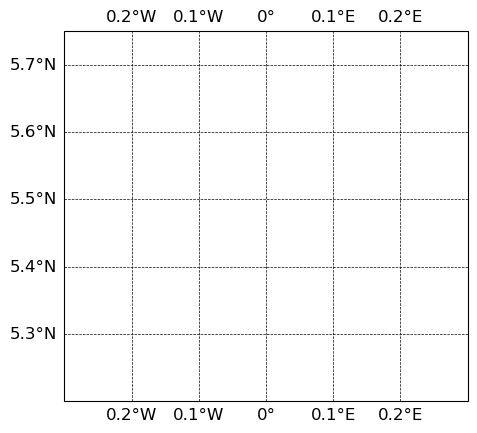

In [42]:
# check
original_cmap = plt.get_cmap('Blues')
# Reverse the colormap
reversed_cmap = mcolors.ListedColormap(original_cmap(np.linspace(0, 1, 256))[::-1])
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
# ax.coastlines()
# ax.add_feature(cartopy.feature.LAND, edgecolor='black', color='lightgray')
gl = ax.gridlines(color='black', linestyle='dashed', draw_labels=True, linewidth=0.5)
gl.right_labels = False
gl.xlabel_style = {'size': 12}  
gl.ylabel_style = {'size': 12}

ax.set_xlim(-0.3, 0.3)
ax.set_ylim(5.2, 5.75)

# include sampled bathy
# plt.scatter(profile_lons, profile_lats, c=transect_depths, cmap='Blues')

# # include all bathy
# plt.scatter(b_lons, b_lats, s=2)
# plt.scatter(b_lons, b_lats, c=b_depths, cmap='Reds')

# include all bathy
# CS = plt.contourf(b_lons, b_lats, df.elevation.values, cmap=reversed_cmap, levels=np.arange(-3000, 0, 20))
# # add colorbar
# import matplotlib.ticker as mticker

# cbar = plt.colorbar(CS, orientation='vertical', pad=0.02, aspect=20, shrink=0.8)
# cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(abs(x))}"))

# cbar.set_label("Depth (m)", fontsize=12)
# cbar.ax.tick_params(labelsize=10)


# c = plt.contour(b_lons, b_lats, df.elevation.values, colors='k', levels=np.arange(-3000, 0, 20), linewidths=0.3)


# plot the regression line
ax.plot(out["transect_lons"], out["transect_lats"], color='r', linestyle='--', linewidth=1, label='Transect Fit')

# plot the coastline
ax.plot(coast_lon, coast_lat, c='k', linewidth=1)

# plot the profile locations and coastal intersection point
plt.scatter(out["profile_lons"], out["profile_lats"], color='blue', label='Profiles', s=10, marker='+')
plt.scatter(out["intersect_lon"], out["intersect_lat"], color='blue', label='Profiles', s=80, marker='*')

plt.scatter(out["profile_lons"][0], out["profile_lats"][0], color='green', s=50, marker='*')


plt.title(f'{cruise} {transect_name} Transect', fontsize=14)

# optional: save figure
# filename = f"{cruise}_{transect_name}_transect_map.png"
# plt.savefig(os.path.join(os.getcwd(),'figures', filename), dpi=300, bbox_inches='tight')


In [7]:
if data_type=='ctd':
    variables = ["CT", "SA", "rho"]
    colors = ["magma", "viridis", "BuPu"]
elif data_type=='oxy':
    variables = ["O2"]
    colors = ["YlGnBu"]
else:
    variables = ["chl_cal", "bb470_cal"]
    colors = ["YlGn", "viridis"]

In [20]:
# data exceptions
if transect_name == 'sakumono' and cruise == '2025-04':
    # remove the last profile
    coords = coords[:-1]
    datasets = datasets[:-1]
    datasets_ctd = datasets_ctd[:-1]
    distance = distance[:-1]
    transect_depths = -transect_depths[:-1]

### (2) plot transects as pcolor 

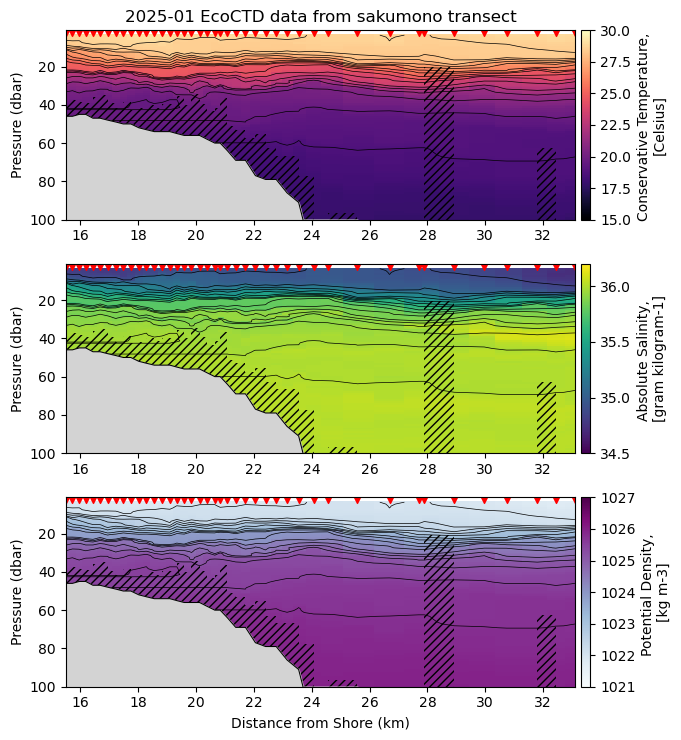

In [21]:
do_interpolate = True
extrapolate = True
ignore_questionable = True
include_topo = True
use_density_contours = True

manual_thresholds = {
    "chl_cal": (0.1, 10), #1.5 #6 for prampram_08AUG!
    "bb470_cal": (0.0, 0.0015),
    "O2": (100, 230),
    "SA": (34.5, 36.2),
    "rho": (1021, 1027),
    "CT": (15, 30) # (16, 30)
}

depth_limit = 100

min_depth = min(ds["seaPress"].min().values for ds in datasets)  # Shallowest recorded depth
max_depth = min(depth_limit, max(ds["seaPress"].max().values for ds in datasets))  

depth_grid = np.linspace(min_depth, max_depth, depth_limit)


# --- Density field from datasets_ctd ---
if use_density_contours:

    min_depth_rho = min(ds["seaPress"].min().values for ds in datasets_ctd)  # Shallowest recorded depth
    max_depth_rho = min(depth_limit, max(ds["seaPress"].max().values for ds in datasets_ctd))  

    depth_grid_rho = np.linspace(min_depth_rho, max_depth_rho, depth_limit)

    rho_profiles_list = []

    for ds_ctd in datasets_ctd:
        P = ds_ctd["seaPress"].values
        SA = ds_ctd["SA"].values
        CT = ds_ctd["CT"].values

        rho = gsw.pot_rho_t_exact(SA, CT, P, 0)

        # manual thresholds
        min_rho, max_rho = manual_thresholds['rho']
        manual_mask_rho = (rho >= min_rho) & (rho <= max_rho)

        # qc filtering
        if "rho_qc" in ds_ctd:
            rho_qc = ds_ctd["rho_qc"].values
            if ignore_questionable:
                qc_mask_rho = rho_qc == 1
            else:
                qc_mask_rho = (rho_qc == 1) | (rho_qc == 0)
        else:
            qc_mask_rho = np.ones_like(rho, dtype=bool)

        valid_mask = (~np.isnan(P)) & (~np.isnan(rho)) & manual_mask_rho & qc_mask_rho
        P_good = P[valid_mask]
        rho_good = rho[valid_mask]

        if P_good.size > 1:
            # vertical interpolation onto depth_grid
            interp_func_rho = interp1d(P_good, rho_good, kind='linear', bounds_error=False)
            rho_interp = interp_func_rho(depth_grid_rho)
        else:
            rho_interp = np.full(depth_grid_rho.shape, np.nan)

        rho_profiles_list.append(rho_interp)

    # stack into (n_depth, n_profiles)
    if len(rho_profiles_list) == 0:
        all_rho_profiles = np.full((depth_grid_rho.size, len(datasets_ctd)), np.nan)
    else:
        all_rho_profiles = np.column_stack(rho_profiles_list)

        # horizontal nearest-neighbor fill if extrapolate=True
        if extrapolate:
            n_depth, n_profiles = all_rho_profiles.shape
            for k in range(n_depth):
                row = all_rho_profiles[k, :]
                valid_idx = np.where(np.isfinite(row))[0]
                if valid_idx.size == 0:
                    continue
                f_nearest = interp1d(
                    valid_idx, row[valid_idx],
                    kind='nearest', bounds_error=False, fill_value='extrapolate'
                )
                all_rho_profiles[k, :] = f_nearest(np.arange(n_profiles))

    # contour levels
    rho_min, rho_max = manual_thresholds['rho']
    rho_levels = np.arange(rho_min, rho_max + 0.25, 0.25)

    # remove bold levels from regular levels
    target_levels = [1026]
    rho_levels = np.array([lvl for lvl in rho_levels if lvl not in target_levels])


fig, axs = plt.subplots(len(variables), 1, figsize=(7, 2.5 * len(variables)))

if len(variables) == 1:
    axs = [axs]

# Loop over variables for datasets
for idx, var in enumerate(variables):  
    
    profiles = np.full((depth_limit, len(datasets)), np.nan)

    ax = axs[idx]

    max_depths = [] 

    for i, ds in enumerate(datasets):

        P = ds["seaPress"].values 
            
        if var in ds:
            V = ds[var].values 

            if var == 'O2':
                V = V*1000

            if var == 'rho':
                # convert to potential density
                SA = ds["SA"].values
                CT = ds["CT"].values
                V = gsw.pot_rho_t_exact(SA, CT, P, 0)

            # qc filtering
            qc_mask = np.ones_like(V, dtype=bool)

            qc_var = f"{var}_qc"
            if qc_var in ds:
                QC = ds[qc_var].values

                # Always exclude -1 (bad), optionally exclude 0 (questionable)
                if ignore_questionable:
                    qc_mask = QC == 1
                else:
                    qc_mask = (QC == 1) | (QC == 0)

            # optional manual filtering
            manual_mask = np.ones_like(V, dtype=bool)
            if var in manual_thresholds:
                min_val, max_val = manual_thresholds[var]
                manual_mask = (V >= min_val) & (V <= max_val)

            valid_mask = ~np.isnan(P) & ~np.isnan(V) & qc_mask & manual_mask
 
            P = P[valid_mask]  
            V = V[valid_mask] 

            # extract maximum depth 
            if P.size > 0:
                max_depths.append(np.nanmax(P))
            else:
                max_depths.append(np.nan)

            if do_interpolate:
                if len(P) > 1:  # only interpolate if there are enough points
                    interp_func = interp1d(P, V, kind='linear', bounds_error=False)
                    interp_values = interp_func(depth_grid)
    
                    profiles[:, i] = interp_values
            else:
                for j, depth in enumerate(P):
                    k = np.argmin(np.abs(depth_grid - depth))  # Find closest depth
                    profiles[k, i] = V[j] 

    nan_mask = np.isnan(profiles)

    if extrapolate:    
        n_depth, n_profiles = profiles.shape

        for k in range(n_depth):
            row = profiles[k, :]

            # find indices of valid values in this row
            valid_idx = np.where(np.isfinite(row))[0]

            if len(valid_idx) == 0:
                continue

            # for each missing value, fill with nearest valid neighbor horizontally
            missing_idx = np.where(~np.isfinite(row))[0]

            for j in missing_idx:
                # find nearest valid profile
                nearest = valid_idx[np.argmin(np.abs(valid_idx - j))]
                row[j] = row[nearest]

            profiles[k, :] = row

    
    X, Y = np.meshgrid(distance, depth_grid)


    if var in manual_thresholds:
        vmin, vmax = manual_thresholds[var]
    else:
        vmin, vmax = np.nanmin(profiles), np.nanmax(profiles)


    if var == "chl_cal":
        # Avoid taking log of zeros or negatives
        profiles = np.where(profiles > 0, np.log10(profiles), np.nan)

        vmin = np.log10(max(vmin, 1e-3))
        vmax = np.log10(max(vmax, 1e-3))

    
    mesh = ax.pcolormesh(X, Y, profiles, shading='auto', cmap=colors[idx], 
                         vmin=vmin, vmax=vmax, zorder=1) # or shading='auto' 'gouraud
    
    if use_density_contours:
        X_r, Y_r = np.meshgrid(distance, depth_grid_rho)

        # if data_type!='ctd':
        #     from scipy.ndimage import uniform_filter1d

        #     all_rho_profiles = uniform_filter1d(all_rho_profiles, size=3, axis=1, mode='nearest')
        contour_data = np.ma.masked_invalid(all_rho_profiles)
        contours = ax.contour(X_r, Y_r, contour_data, colors='black', linewidths=0.5, levels=rho_levels, zorder=2)

    else:
        contour_data = np.ma.masked_invalid(profiles)
        contours = ax.contour(X, Y, contour_data, colors='black', linewidths=0.5, levels=rho_levels, zorder=2)

    # Bold contour for 1026
    if use_density_contours:
        manual_positions_all = []

        for lvl in target_levels:
            cs_bold = ax.contour(X_r, Y_r, contour_data, levels=[lvl], colors='black', linewidths=1)

            # Find points near distance[-5] for manual label placement
            x_label = distance[-5]
            manual_positions = []

            if cs_bold.allsegs[0]:  # check that there are segments
                for seg in cs_bold.allsegs[0]:  # all segments for this level
                    if seg.size == 0:
                        continue
                    mask = seg[:, 0] >= x_label
                    if np.any(mask):
                        ix = np.argmax(mask)
                        manual_positions.append((seg[ix, 0], seg[ix, 1]))
                        break  # one label per contour

            # Label this bold contour
            if manual_positions:
                ax.clabel(cs_bold, fmt='%d', fontsize=8, inline=True, manual=manual_positions)


    # add hatching for extrapolated regions
    if extrapolate:
        nrows, ncols = X.shape

        for j in range(ncols - 1):  # loop over profile columns

             # rectangle corners
            x0, x1 = X[0, j], X[0, j+1]
            y0 = max_depths[j] 
            if np.isnan(max_depths[j]):
                y0 = 5 
            y1 = depth_limit

            rect = plt.Rectangle(
                (x0, y0),
                x1 - x0,
                y1 - y0,
                fill=False,
                edgecolor="black",
                linewidth=0,
                hatch="////",
                zorder=3
            )
            ax.add_patch(rect)
    
    cbar = plt.colorbar(mesh, ax=ax, pad=0.01) 
    if data_type=='oxy':
        cbar.set_label(f"Oxygen Concentration, \n[mmol m-3]")
    elif var=='rho':
        cbar.set_label(f"Potential Density, \n[kg m-3]")
    elif var=='chl_cal':
        cbar.set_label(f"Chlorophyll-Fluorescence, \nmg L⁻¹)")
        ticks = [0.1, 1.0, 10.0]  # example
        cbar.set_ticks(np.log10(ticks))
        cbar.set_ticklabels([str(t) for t in ticks])
    elif var=='bb470_cal':
        # scale factor
        scale = 1e3
        cbar.set_ticks([0.0, 0.5e-3, 1.0e-3, 1.5e-3])  # positions in original units, 2.0e-3
        cbar.set_ticklabels([f"{t*scale:.1f}" for t in [0.0, 0.5e-3, 1.0e-3, 1.5e-3]])
        cbar.set_label("Backscatter at 470nm, \n×10⁻³ [m⁻¹ steradian⁻¹]")
    else:
        cbar.set_label(f"{ds[var].long_name}, \n[{ds[var].units}]") 
    
    ax.scatter(distance, [min_depth] * len(distance), color='red', marker='v', s=50, label="Profile Locations", zorder=5)

    if idx==len(variables)-1: ax.set_xlabel("Distance from Shore (km)")
    ax.set_ylabel("Pressure (dbar)") #"Pressure (dbar)"; "Depth (m)"
    ax.invert_yaxis()  
    if idx==0: ax.set_title(f"{cruise} EcoCTD data from {transect_name} transect")
    ax.set_xlim(distance[0], distance[-1])

    dist_arr = np.array(distance)
    topo_arr = np.array(transect_depths)

    if include_topo:
        if topo_arr[0] < 0:
            topo_arr = -topo_arr

        ax.plot(dist_arr, topo_arr, color='k', linewidth=0.75, label='Topography', zorder=4)

        mask = ~np.isnan(topo_arr)
        ax.fill_between(
            dist_arr[mask],
            topo_arr[mask],
            y2=depth_limit,
            color='lightgray',
            alpha=1,
            zorder=3,
        )

    ax.set_ylim(depth_limit,min_depth-0.5)
    
    if transect_name == 'sakumono' and cruise == '2025-April':
        ax.set_xlim(distance[25], distance[-2]) # this is for April Sakumono which has some very short inshore profiles

    for spine in ax.spines.values():
        spine.set_zorder(100)
    
    ax.tick_params(zorder=100)

    # optional vertical lines to indicate mooring location (roughly)
    # ax.plot([distance[21], distance[21]], [100, 10], color='k', linewidth=2)
    # ax.plot([distance[49], distance[49]], [100, 40], color='k', linewidth=2)

plt.tight_layout()
plt.show()


In [126]:
filename = f"{cruise}_{transect_name}_{data_type}_{depth_limit}m-2.png"
fig.savefig(os.path.join(os.getcwd(),'figures', filename))

### (3) Make T-S Diagram of all profiles

#### simple TS diagram

In [3]:
def T_S_diagram(transects, cruise, color, ax, add_density_contours=True):

    # Plot data from each transect and assign a label to the first one only
    labeled = False
    for j, transect_name in enumerate(transects):
        wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
        ctd = glob.glob(wkdir + '*ctd.nc')
        datasets = [xr.open_dataset(f) for f in ctd]

        for ds in datasets:
            p = ds["seaPress"].values
            t = ds["T"].values
            sa = ds["SA"].values

            # Mask out NaNs and shallow data
            mask = np.isfinite(p) & np.isfinite(t) & np.isfinite(sa) & (p > 10)
            if not np.any(mask):
                continue

            p, t, sa = p[mask], t[mask], sa[mask]
            pt = gsw.pt_from_t(sa, t, p, 0)

            # Mask potential temperature
            mask2 = np.isfinite(pt)
            sa, pt = sa[mask2], pt[mask2]

            if not labeled:
                ax.scatter(sa, pt, s=1, color=color, label=f'{cruise}')
                labeled = True
            else:
                ax.scatter(sa, pt, s=1, color=color)

                ax.scatter(sa, pt, s=1, color=color)



#### inshore v offshore TS diagram

Helper function that tags values in a dataset as onshore and offshore

In [4]:
from scipy.interpolate import RegularGridInterpolator

def load_bathymetry_interpolator(bathy_path):
    """
    Load GEBCO bathymetry and return a callable interpolator function.
    """
    df = xr.open_dataset(bathy_path)
    b_lats = df["lat"].values
    b_lons = df["lon"].values
    b_depths = df["elevation"].values  # negative = below sea level

    interp_func = RegularGridInterpolator(
        (b_lats[::-1], b_lons),
        b_depths[::-1, :],
        bounds_error=False,
        fill_value=np.nan
    )

    return interp_func

def tag_onshore_offshore(ds, bathy_interp, depth_thresh=-200):
    """
    Tag points as onshore (>= depth_thresh) or offshore (< depth_thresh)
    using a precomputed bathymetry interpolator.
    """
    if "lat" not in ds or "lon" not in ds:
        raise ValueError("Dataset must contain 'lat' and 'lon' variables")

    lat = ds["lat"].values
    lon = ds["lon"].values
    coords = np.column_stack((lat.ravel(), lon.ravel()))

    depth_interp = bathy_interp(coords).reshape(lat.shape)
    return depth_interp < depth_thresh



In [5]:
bathy_interp = load_bathymetry_interpolator('GIS_data/gebco_2023_n12.0_s-12.0_w-21.0_e16.0.nc')

In [6]:
def T_S_diagram_onshore_offshore(
    transects,
    cruise,
    ax,
    bathy_interp,
    region='both'  # 'onshore', 'offshore', or 'both'
):
    """
    Plot T-S diagram for a cruise, with onshore/offshore tagging.

    Parameters
    ----------
    transects : list
        List of transect names
    cruise : str
        Cruise name (used for color selection)
    ax : matplotlib axis
        Axis to plot on
    bathy_interp : callable
        Precomputed bathymetry interpolator
    add_density_contours : bool
        Whether to overlay potential density contours
    region : str
        'onshore', 'offshore', or 'both' to plot only that subset
    """
    light_color, dark_color = cruise_colors[cruise]

    labeled = False

    for transect_name in transects:
        wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
        ctd_files = glob.glob(wkdir + '*ctd.nc')
        datasets = [xr.open_dataset(f) for f in ctd_files]

        # datasets = datasets[10:15]

        for ds in datasets:
            # Tag offshore/onshore
            is_offshore = tag_onshore_offshore(ds, bathy_interp)

            p = ds["seaPress"].values
            t = ds["T"].values
            sa = ds["SA"].values

            # Mask NaNs and shallow measurements
            mask = np.isfinite(p) & np.isfinite(t) & np.isfinite(sa) & (p > 10)
            if not np.any(mask):
                continue

            p, t, sa, is_offshore = p[mask], t[mask], sa[mask], is_offshore[mask]
            pt = gsw.pt_from_t(sa, t, p, 0)
            mask2 = np.isfinite(pt)
            sa, pt, is_offshore = sa[mask2], pt[mask2], is_offshore[mask2]

            # Select region
            if region == 'onshore':
                region_mask = ~is_offshore
            elif region == 'offshore':
                region_mask = is_offshore
            else:
                region_mask = np.ones_like(is_offshore, dtype=bool)

            # Skip if no points in this region
            if not np.any(region_mask):
                continue

            sa, pt, is_offshore = sa[region_mask], pt[region_mask], is_offshore[region_mask]
            color_array = [dark_color if flag else light_color for flag in is_offshore]

            # Add legend only once
            if not labeled:
                ax.scatter([], [], s=10, color=light_color, label=f"{cruise} (onshore)")
                ax.scatter([], [], s=10, color=dark_color, label=f"{cruise} (offshore)")
                labeled = True

            # Plot points
            ax.scatter(sa, pt, s=2, color=color_array)




#### by depth

In [7]:
def T_S_diagram_by_depth(
    transects,
    cruise,
    ax,
    vmin=None,
    vmax=None,
    cmap='viridis'
):
    """
    Plot T–S diagram for a cruise, colored by depth (m).
    """
    og_cmap = plt.get_cmap(cmap)
    # Reverse the colormap
    cmap = mcolors.ListedColormap(og_cmap(np.linspace(0, 1, 256))[::-1])

    scatter = None

    for transect_name in transects:
        wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
        ctd_files = glob.glob(wkdir + '*ctd.nc')
        datasets = [xr.open_dataset(f) for f in ctd_files]

        for ds in datasets:
            p = ds["seaPress"].values
            t = ds["T"].values
            sa = ds["SA"].values
            lat = ds["lat"].values

            mask = np.isfinite(p) & np.isfinite(t) & np.isfinite(sa) & (p > 10)
            if not np.any(mask):
                continue

            p, t, sa, lat = p[mask], t[mask], sa[mask], lat[mask]
            ct = gsw.CT_from_t(sa, t, p)

            mask2 = np.isfinite(ct)
            sa, ct, p, lat = sa[mask2], ct[mask2], p[mask2], lat[mask2]

            # Compute depth (positive downward)
            depth = -gsw.z_from_p(p, lat)

            # Scatter colored by depth
            scatter = ax.scatter(sa, ct, c=depth, s=3, cmap=cmap, vmin=vmin, vmax=vmax, zorder=3)

    # Add colorbar once after all transects are plotted
    # if scatter is not None:
    #     cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
    #     cbar.set_label("Depth (m)")
    return scatter


#### by chlorophyll

In [ ]:
from matplotlib.colors import LogNorm

def T_S_diagram_by_chl(
    transects,
    cruise,
    ax,
    vmin=0.01,     # sensible default for chl (mg/L)
    vmax=10,
    cmap='YlGn'
):
    """
    Plot T–S diagram for a cruise, colored by chlorophyll fluorescence (mg/L),
    using a logarithmic color scale.
    """
    scatter = None

    for transect_name in transects:
        wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
        ctd_files = sorted(glob.glob(wkdir + '*ctd.nc'))
        chl_files = sorted(glob.glob(wkdir + '*fls.nc'))
        if not ctd_files or not chl_files:
            continue

        for ctd_file, chl_file in zip(ctd_files, chl_files):
            with xr.open_dataset(ctd_file) as ds, xr.open_dataset(chl_file) as chl_ds:
                p = ds["seaPress"].values
                t = ds["T"].values
                sa = ds["SA"].values
                lat = float(ds["lat"].values.mean())

                valid = np.isfinite(p) & np.isfinite(t) & np.isfinite(sa) & (p > 10)
                if not np.any(valid):
                    continue

                p, t, sa = p[valid], t[valid], sa[valid]
                pt = gsw.pt_from_t(sa, t, p, 0)

                chl = chl_ds["chl_cal"].values
                chl_p = chl_ds["seaPress"].values
                if len(chl) < 2:
                    continue

                chl_at_ctd = np.interp(p, chl_p, chl, left=np.nan, right=np.nan)
                chl_at_ctd = np.where(chl_at_ctd > 0, chl_at_ctd, np.nan)  # avoid log(0)

                scatter = ax.scatter(
                    sa, pt,
                    c=chl_at_ctd,
                    s=1,
                    cmap=cmap,
                    norm=LogNorm(vmin=vmin, vmax=vmax)
                )

    if scatter is not None:
        cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
        cbar.set_label("Chlorophyll Fluorescence [mg/L] (log scale)")

    ax.set_xlabel("Absolute Salinity [g/kg]")
    ax.set_ylabel("Potential Temperature [°C]")
    ax.set_title(f"T–S diagram ({cruise})")


#### mixed

In [ ]:
def depth_weighted_mix(p, SA, CT):
    """
    Compute depth-weighted average SA, CT, and resulting mixed density.
    """
    # Convert pressure to depth (meters, positive downward)
    # If latitude is unknown, 0° is fine (affects depth <0.5%).
    z = -gsw.z_from_p(p, 0)

    # Sort by depth (just in case)
    idx = np.argsort(z)
    z = z[idx]
    SA = SA[idx]
    CT = CT[idx]

    # Compute layer thicknesses Δz
    dz = np.diff(z)
    # Match length: treat bottom layer thickness = same as second-to-last
    dz = np.concatenate([dz, [dz[-1]]])

    # Weighted averages
    SA_mix = np.sum(SA * dz) / np.sum(dz)
    CT_mix = np.sum(CT * dz) / np.sum(dz)

    # Density at surface pressure (0 dbar)
    rho_mix = gsw.rho(SA_mix, CT_mix, 0)

    sigma0 = gsw.density.sigma0(SA_mix, CT_mix)

    return SA_mix, CT_mix, rho_mix, sigma0

In [ ]:
def Mixed_TS_diagram_onshore_offshore(
        transects, cruise, ax, bathy_interp,
        region='both',
        marker='o', s=50
    ):
    """
    Plot vertically mixed T–S points for each CTD profile,
    colored by onshore/offshore like your other diagram function.
    """

    light_color, dark_color = cruise_colors[cruise]
    labeled = False  # only add legend entries once

    for transect_name in transects:
        wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
        ctd_files = glob.glob(wkdir + "*ctd.nc")
        datasets = [xr.open_dataset(f) for f in ctd_files]

        # datasets = datasets[10:15]

        for ds in datasets:

            # Tag each point as on/offshore
            is_offshore_flags = tag_onshore_offshore(ds, bathy_interp)

            p = ds["seaPress"].values
            t = ds["T"].values
            SA = ds["SA"].values

            # Mask
            mask = np.isfinite(p) & np.isfinite(t) & np.isfinite(SA) & (p > 10)
            if not np.any(mask):
                continue

            p, t, SA, is_offshore_flags = (
                p[mask], t[mask], SA[mask], is_offshore_flags[mask]
            )

            CT = gsw.CT_from_t(SA, t, p)

            # Region selection
            if region == 'onshore':
                region_mask = ~is_offshore_flags
            elif region == 'offshore':
                region_mask = is_offshore_flags
            else:
                region_mask = np.ones_like(is_offshore_flags, dtype=bool)

            if not np.any(region_mask):
                continue

            # Extract region profile
            p_r = p[region_mask]
            SA_r = SA[region_mask]
            CT_r = CT[region_mask]

            # Compute vertically mixed values
            SA_mix, CT_mix, rho_mix, sigma0_mix = depth_weighted_mix(p_r, SA_r, CT_r)

            # Convert CT_mix → potential temperature for plotting
            pt_mix = gsw.pt_from_CT(SA_mix, CT_mix)

            # Determine color
            offshore_flag = bool(is_offshore_flags[region_mask][0])
            color = dark_color if offshore_flag else light_color

            # Add legend entries only once
            if not labeled:
                ax.scatter([], [], s=s, marker=marker, color=light_color,
                           label=f"{cruise} mixed (onshore)")
                ax.scatter([], [], s=s, marker=marker, color=dark_color,
                           label=f"{cruise} mixed (offshore)")
                labeled = True

            # Plot the mixed point
            ax.scatter(SA_mix, pt_mix, s=s, marker=marker,
                       edgecolor='black', color=color, zorder=15)


#### make diagram

In [8]:
# cruise_colors = {
#     "2025-Jan-Pilot": ("#ffa7ce", "#AA1b59"),
#     "2025-April": ("#a8c2ff", "#274cbe"),
#     "2025-Summer": ("#d7b2ff", "#6b30bf"),
#     "2025-November": ("#afffda", "#347a7a"),
#     "2025-December": ("#ffc6a0", "#CF6800")
# }

cruise_colors = {
    "2025-Jan-Pilot": ("#ff6b6b", "#b00202"),  # red
    "2025-April": ("#4d91f7", "#082ad5"),     # blue
    "2025-Summer": ("#ffd43b", "#f0b208"),    # yellow
    "2025-November": ("#f18bfa", "#6d0d85"),  # purple
    "2025-December": ("#78e98b", "#2f9e44"),  # green
}


3 transects from 2025-08 called: ['test', 'prampram_8AUG', 'prampram_13AUG']


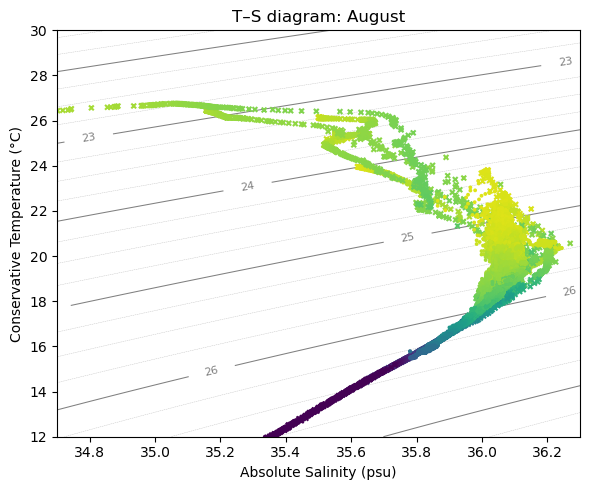

In [15]:
# cruises = ['2025-Jan-Pilot','2025-April','2025-Summer','2025-November', '2025-December']
# cruises = ['2025-December','2025-April', '2025-November','2025-Jan-Pilot','2025-Summer']
cruises = ['2025-08']
cruise_names = ['August']

# cruise_names = ['January', 'April', 'August', 'November', 'December']
# cruise_names = ['December', 'April', 'November', 'January', 'Summer']

fig, ax = plt.subplots(figsize=(6, 5))

argo = True
argo_color_by_depth = True

inshore_offshore = False
by_depth = True
by_chl = False

DEPTH_VMIN = 0
DEPTH_VMAX = 200

if sum([inshore_offshore, by_depth, by_chl]) > 1:
    raise ValueError("At most one of these flags can be True: inshore_offshore, by_depth, by_chl")

# # Density contours
# sas = np.linspace(34, 37, 100)
# cts = np.linspace(12, 30, 100)
# sigma_grid = np.array([[gsw.sigma0(sa, ct) for sa in sas] for ct in cts])
# levels = np.linspace(20, 30, 30)
# CS = ax.contour(sas, cts, sigma_grid, levels=levels, colors='gray', linewidths=0.5, zorder=1)

# # Label iso-lines
# x_vals = np.linspace(34.25, 36.25, 5)  
# y_intercepts = [40, 30, 20]  
# label_positions = [
#     (x, -6 * (x - 34) + b)  
#     for b in y_intercepts
#     for x in x_vals
#     if 12 <= -5 * (x - 34) + b <= 32
# ]

# ax.clabel(CS, inline=True, fontsize=8, fmt="%.1f", use_clabeltext=True, manual=label_positions)

# include contours 
# grid
sas = np.linspace(34, 37, 200)
cts = np.linspace(12, 30, 200)
sigma_grid = np.array([[gsw.sigma0(sa, ct) for sa in sas] for ct in cts])

# define contour levels
major_levels = np.arange(20, 28, 1)       # 24, 25, 26, 27
minor_levels = np.arange(20, 28, 0.25)    # 0.25 spacing

# remove majors from minors so they don't overplot
minor_levels = np.setdiff1d(minor_levels, major_levels)

# --- minor contours (thin, no labels)
CS_minor = ax.contour(
    sas, cts, sigma_grid,
    levels=minor_levels,
    colors='gray',
    linewidths=0.3,
    linestyles='dashed',
    alpha=0.5,
    zorder=0
)

# --- major contours (thicker, labeled)
CS_major = ax.contour(
    sas, cts, sigma_grid,
    levels=major_levels,
    colors='gray',
    linewidths=0.75,
    zorder=1
)

# --- manual label placement (ONLY for majors)
x_vals = np.linspace(34.25, 36.25, 5)
y_intercepts = [40, 30, 20]

label_positions = [
    (x, -5 * (x - 34) + b)
    for b in y_intercepts
    for x in x_vals
    if 12 <= -5 * (x - 34) + b <= 30
]

ax.clabel(
    CS_major,
    inline=True,
    fontsize=8,
    fmt="%.0f",   # integers only
    use_clabeltext=True,
    manual=label_positions
)

for i, cruise in enumerate(cruises):
    path = Path(f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/")
    if cruise == '2025-Jan-Pilot':
        ignore = {'calibration', 'shakedown'}
    elif cruise == '2025-08':
        ignore = {'shakedown_day1', 'shakedown_day2', 'jamestown', 'sakumono', 'prampram_8AUG', 'prampram_13AUG'}
    elif cruise == '2025-April':
        ignore = {'jamestown'}
    elif cruise == '2025-December':
        ignore = {'prampram'}
    else:
        ignore = {}

    transects = [f.name for f in path.iterdir() if f.is_dir() and f.name.lower() not in ignore]
    print(len(transects), "transects from", cruise, "called:", transects)
    
    # optional add argo data
    if cruise == '2025-08' and argo:
        # overlay Argo data from same period
        wkdir = f"{os.environ['WINPATH']}/OneDrive - Massachusetts Institute of Technology/mit-whoi/gulf_of_guinea/argo/"
        argo = glob.glob(wkdir + '*.nc')
        argo_datasets = [xr.open_dataset(f) for f in argo]

        for ds in argo_datasets:
            times = ds["TIME"].values  # number of profiles
            nprof = len(times)

            for i in range(nprof):
                p = ds["PRES"].isel(TIME=i).values
                t = ds["TEMP"].isel(TIME=i).values
                sp = ds["PSAL"].isel(TIME=i).values

                lon = ds["LONGITUDE"].isel(TIME=i).values
                lat = ds["LATITUDE"].isel(TIME=i).values

                # Combined mask (do it once)
                mask = (
                    np.isfinite(p) &
                    np.isfinite(t) &
                    np.isfinite(sp) &
                    (p > 10)
                )

                if not np.any(mask):
                    continue

                # Apply mask once
                p = p[mask]
                t = t[mask]
                sp = sp[mask]

                # Absolute Salinity
                sa = gsw.SA_from_SP(sp, p, lon, lat)

                # Potential temperature
                pt = gsw.pt_from_t(sa, t, p, 0)

                # Secondary mask (on pt)
                mask2 = np.isfinite(pt)

                sa = sa[mask2]
                pt = pt[mask2]
                p = p[mask2]

                # Depth (matches final filtered arrays!)
                depth = -gsw.z_from_p(p, lat)

                # -- PLOT COLORED BY DEPTH --
                if argo_color_by_depth:
                    ax.scatter(
                        sa, pt,
                        s=12,
                        c= depth,#np.full_like(sa, i),
                        cmap="viridis_r",
                        vmin=DEPTH_VMIN,
                        vmax=DEPTH_VMAX,#nprof - 1,
                        marker='x',
                        label='Argo profiles' if i == 0 else None
                    )
                else:
                    ax.scatter(
                        sa, pt,
                        s=12,
                        color='k',
                        marker='x',
                        label='Argo profiles' if i == 0 else None
                    )

            # Add a single colorbar for this dataset
            # cbar = plt.colorbar(ax.collections[-1], ax=ax)
            # cbar.set_label("Argo Profile Number")


                
    if inshore_offshore:
        T_S_diagram_onshore_offshore(transects, cruise, ax, bathy_interp, region='both')
        # Mixed_TS_diagram_onshore_offshore(transects, cruise, ax, bathy_interp, region='both')
    elif by_depth:
        scatter = T_S_diagram_by_depth(transects, cruise, ax, vmin=DEPTH_VMIN, vmax=DEPTH_VMAX)
        if i == 0:
            cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
            cbar.set_label("Depth (m)")
    elif by_chl:
        T_S_diagram_by_chl(transects, cruise, ax, vmin=0.01, vmax=10, cmap='viridis')
    else:
        T_S_diagram(transects, cruise, cruise_colors[cruise][1], ax)

# Final labeling and display
ax.set_xlabel("Absolute Salinity (psu)")
ax.set_ylabel("Conservative Temperature (°C)")
ax.set_title(f"T–S diagram: {', '.join(cruise_names)}")
# ax.set_title(f"T-S diagram for {[cruise for cruise in cruises]}")
ax.set_xlim([34.7, 36.3]) # [34.5,36.5]
ax.set_ylim([12, 30]) # [12,32]
if not by_depth:
    ax.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
filename = f"T-S-diagram-depth-{'-'.join(cruise_names)}.png"
fig.savefig(os.path.join(os.getcwd(),'figures', filename))

4 transects from 2025-Jan-Pilot
3 transects from 2025-April
4 transects from 2025-Summer
4 transects from 2025-November


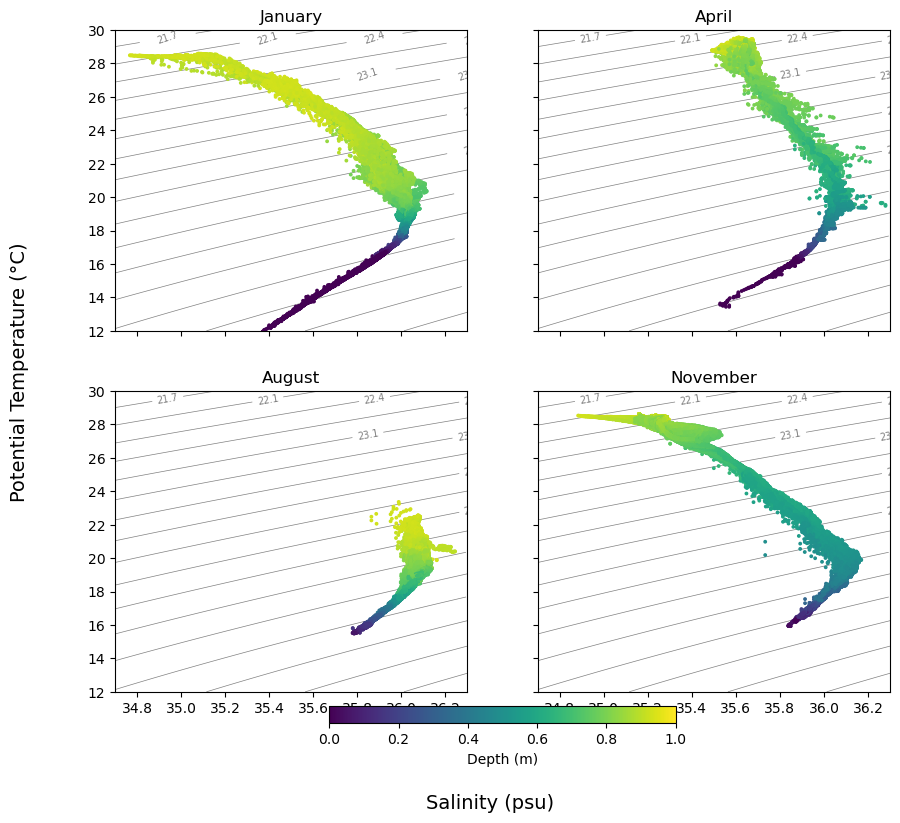

In [ ]:
cruises = ['2025-Jan-Pilot', '2025-April',
           '2025-Summer', '2025-November']

cruise_names = ['January', 'April', 'August', 'November']

# --- Create 2x2 layout ---
fig, axs = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
axs = axs.flatten()

argo = False
inshore_offshore = False
by_depth = True
by_chl = False

if sum([inshore_offshore, by_depth, by_chl]) > 1:
    raise ValueError("At most one of these flags can be True.")

# Density grid (compute once)
sas = np.linspace(34, 37, 100)
cts = np.linspace(12, 30, 100)
sigma_grid = np.array([[gsw.sigma0(sa, ct) for sa in sas] for ct in cts])
levels = np.linspace(20, 30, 30)

# To store last scatter for shared colorbar
mappable = None

for i, cruise in enumerate(cruises):

    ax = axs[i]

    # --- Density contours ---
    CS = ax.contour(
        sas, cts, sigma_grid,
        levels=levels,
        colors='gray',
        linewidths=0.5,
        zorder=1
    )

    ax.clabel(CS, inline=True, fontsize=7, fmt="%.1f")

    # --- Load cruise data ---
    path = Path(f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/")

    if cruise == '2025-Jan-Pilot':
        ignore = {'calibration', 'shakedown'}
    elif cruise == '2025-Summer':
        ignore = {'shakedown_day1', 'shakedown_day2', 'test'}
    else:
        ignore = {}

    transects = [
        f.name for f in path.iterdir()
        if f.is_dir() and f.name.lower() not in ignore
    ]

    print(len(transects), "transects from", cruise)

    # --- Plotting modes ---
    if inshore_offshore:
        T_S_diagram_onshore_offshore(transects, cruise, ax, bathy_interp, region='both')

    elif by_depth:
        mappable = T_S_diagram_by_depth(
            transects, cruise, cruise_names[i], ax,
            vmin=0, vmax=150
        )

    elif by_chl:
        mappable = T_S_diagram_by_chl(
            transects, cruise, ax,
            vmin=0.01, vmax=10, cmap='viridis'
        )

    else:
        T_S_diagram(transects, cruise, cruise_colors[cruise][1], ax)

    # Titles for each panel
    ax.set_title(cruise_names[i], fontsize=12)

    # Axis limits
    ax.set_xlim([34.7, 36.3])
    ax.set_ylim([12, 30])

# --- Clean up interior labels ---
for ax in axs:
    ax.label_outer()   # hides interior tick labels automatically

# --- Shared axis labels ---
fig.supxlabel("Salinity (psu)", fontsize=14)
fig.supylabel("Potential Temperature (°C)", fontsize=14)

# --- Shared colorbar (only if depth or chl coloring) ---
if by_depth or by_chl:
    cbar = fig.colorbar(
        mappable,
        ax=axs,
        orientation='horizontal',
        fraction=0.025,
        pad=0.02
    )
    if by_depth:
        cbar.set_label("Depth (m)")
    elif by_chl:
        cbar.set_label("Chlorophyll")

# plt.tight_layout()
plt.show()

### Vertical movement of the mean isopycnal depth

In [2]:
def find_isopycnal_depth(
    sigma,
    depth,
    target_sigma,
    method="shallowest",
    density_buffer=0.0,
    min_bottom_margin=5.0
):
    sigma = np.asarray(sigma, dtype=float)
    depth = np.asarray(depth, dtype=float)

    # remove invalid values
    valid = np.isfinite(sigma) & np.isfinite(depth)
    sigma = sigma[valid]
    depth = depth[valid]

    if len(sigma) < 2:
        return np.nan

    # sort by depth, just in case
    order = np.argsort(depth)
    sigma = sigma[order]
    depth = depth[order]

    # require the profile to span the target density
    if not (
        np.nanmin(sigma) <= target_sigma - density_buffer and
        np.nanmax(sigma) >= target_sigma + density_buffer
    ):
        return np.nan

    diff = sigma - target_sigma

    if method == "closest":
        i = np.nanargmin(np.abs(diff))
        z_iso = depth[i]

    else:
        crossings = np.where(
            ((diff[:-1] <= 0) & (diff[1:] >= 0)) |
            ((diff[:-1] >= 0) & (diff[1:] <= 0))
        )[0]

        if len(crossings) == 0:
            if target < np.nanmin(sigma):
                # isopycnal is lighter than the whole observed profile,
                # so treat it as outcropped / at the surface
                z_iso[target] = 0.0
            elif target > np.nanmax(sigma):
                # isopycnal is denser than the deepest observed profile,
                # so it was not reached
                z_iso[target] = np.nan
            else:
                # no clean crossing, likely due to inversions/noise
                z_iso[target] = np.nan

        if method == "shallowest":
            i = crossings[0]
        elif method == "deepest":
            i = crossings[-1]
        elif method == "closest_to_middepth":
            mid = 0.5 * (depth.min() + depth.max())
            crossing_depths = 0.5 * (depth[crossings] + depth[crossings + 1])
            i = crossings[np.argmin(np.abs(crossing_depths - mid))]
        else:
            raise ValueError(
                "method must be 'closest', 'shallowest', 'deepest', or 'closest_to_middepth'"
            )

        s1, s2 = sigma[i], sigma[i + 1]
        z1, z2 = depth[i], depth[i + 1]

        if s1 == target_sigma:
            z_iso = z1
        elif s2 == target_sigma:
            z_iso = z2
        elif s1 == s2:
            return np.nan
        else:
            z_iso = z1 + (target_sigma - s1) * (z2 - z1) / (s2 - s1)

    # require crossing to be safely above deepest sampled point
    if depth.max() - z_iso < min_bottom_margin:
        return np.nan

    return z_iso

In [3]:
def mean_isopycnal_depth_by_cruise(transects, cruise, target_sigma):
    iso_depths = []

    for transect_name in transects:
        OMIPATH_temp = '/mnt/h/Shared drives/OMI Share'
        wkdir = f"{OMIPATH_temp}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
        ctd_files = glob.glob(wkdir + '*ctd.nc')
        datasets = [xr.open_dataset(f) for f in ctd_files]

        for ds in datasets:
            p = ds["seaPress"].values
            t = ds["T"].values
            sa = ds["SA"].values
            lat = ds["lat"].values

            mask = np.isfinite(p) & np.isfinite(t) & np.isfinite(sa) & np.isfinite(lat) & (p > 5)
            if not np.any(mask):
                continue

            p = p[mask]
            t = t[mask]
            sa = sa[mask]
            lat = lat[mask]

            # sort by pressure to preserve vertical structure
            sort_idx = np.argsort(p)
            p = p[sort_idx]
            t = t[sort_idx]
            sa = sa[sort_idx]
            lat = lat[sort_idx]

            ct = gsw.CT_from_t(sa, t, p)

            mask2 = np.isfinite(ct)
            if np.sum(mask2) < 2:
                continue

            sa = sa[mask2]
            ct = ct[mask2]
            p = p[mask2]
            lat = lat[mask2]

            depth = -gsw.z_from_p(p, lat)
            sigma = gsw.sigma0(sa, ct)

            z_iso = find_isopycnal_depth(
                sigma,
                depth,
                target_sigma,
                method="shallowest",
                density_buffer=0.0,
                min_bottom_margin=1.0
            )
            
            iso_depths.append(z_iso)

    if len(iso_depths) == 0:
        mean = np.nan
        std = np.nan
        median = np.nan
        q25 = np.nan
        q75 = np.nan
        n = 0
        return mean, std, median, q25, q75, n

    return (
        np.nanmean(iso_depths),
        np.nanstd(iso_depths),
        np.nanmedian(iso_depths),
        np.nanpercentile(iso_depths, 25),
        np.nanpercentile(iso_depths, 75),
        np.sum(np.isfinite(iso_depths))
    )

In [4]:
cruises = [
    '2025-Jan-Pilot',
    '2025-April',
    '2025-Summer',
    '2025-November',
    '2025-December'
]

target_sigmas = np.arange(23, 26.25, 0.25)

results = {
    sigma: {
        "mean": [],
        "std": [],
        "median": [],
        "q25": [],
        "q75": [],
        "n": []
    }
    for sigma in target_sigmas
}

for cruise in cruises:
    OMIPATH_temp = '/mnt/h/Shared drives/OMI Share'
    path = Path(f"{OMIPATH_temp}/Coastal Measurements/{cruise}/EcoCTD/data/")
    # path = Path(f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/")

    if cruise == '2025-Jan-Pilot':
        ignore = {'calibration', 'shakedown'}
    elif cruise == '2025-Summer':
        ignore = {'shakedown_day1', 'shakedown_day2', 'test'}
    elif cruise == '2025-April':
        ignore = {'jamestown'}
    elif cruise == '2025-December':
        ignore = {'prampram'}
    else:
        ignore = {}

    transects = [
        f.name for f in path.iterdir()
        if f.is_dir() and f.name.lower() not in ignore
    ]

    for sigma in target_sigmas:
        z_mean, z_std, z_median, z_q25, z_q75, n = mean_isopycnal_depth_by_cruise(
            transects, cruise, sigma
        )

        results[sigma]["mean"].append(z_mean)
        results[sigma]["std"].append(z_std)
        results[sigma]["median"].append(z_median)
        results[sigma]["q25"].append(z_q25)
        results[sigma]["q75"].append(z_q75)
        results[sigma]["n"].append(n)

# debug
# print(results[25]["mean"])

/tmp/ipykernel_1658798/1854647524.py:67: RuntimeWarning: Mean of empty slice
  np.nanmean(iso_depths),
/home/jvynn/anaconda3/envs/lab/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1658798/1854647524.py:69: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(iso_depths),
/home/jvynn/anaconda3/envs/lab/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


In [ ]:
cruise = '2025-November'
transects = ['sakumono']
sigma = 25
z_mean, z_std, z_median, z_q25, z_q75, n = mean_isopycnal_depth_by_cruise(transects, cruise, sigma)
print(f"Mean depth of sigma={sigma} for {cruise}: {z_mean:.1f} m (n={n})")

Mean depth of sigma=25 for 2025-November: 68.6 m (n=29)


In [ ]:
def debug_isopycnal_crossing(ds, target_sigma=26):
    p = ds["seaPress"].values
    sa = ds["SA"].values
    lat = ds["lat"].values

    # IMPORTANT: use CT directly if available
    if "CT" in ds:
        ct = ds["CT"].values
    else:
        t = ds["T"].values
        ct = gsw.CT_from_t(sa, t, p)

    # handle scalar latitude
    if np.ndim(lat) == 0:
        lat = np.full_like(p, float(lat))

    mask = (
        np.isfinite(p) &
        np.isfinite(sa) &
        np.isfinite(ct) &
        np.isfinite(lat) &
        (p > 5)
    )

    p = p[mask]
    sa = sa[mask]
    ct = ct[mask]
    lat = lat[mask]

    idx = np.argsort(p)
    p = p[idx]
    sa = sa[idx]
    ct = ct[idx]
    lat = lat[idx]

    depth = -gsw.z_from_p(p, lat)
    sigma = gsw.sigma0(sa, ct)

    diff = sigma - target_sigma

    crossings = np.where(
        ((diff[:-1] <= 0) & (diff[1:] >= 0)) |
        ((diff[:-1] >= 0) & (diff[1:] <= 0))
    )[0]

    print("sigma min/max:", np.nanmin(sigma), np.nanmax(sigma))
    print("depth min/max:", np.nanmin(depth), np.nanmax(depth))
    print("number of crossings:", len(crossings))

    for i in crossings:
        print(
            f"crossing bracket idx={i}: "
            f"depth {depth[i]:.2f}–{depth[i+1]:.2f}, "
            f"sigma {sigma[i]:.4f}–{sigma[i+1]:.4f}"
        )

    # closest-point diagnostic
    i_close = np.nanargmin(np.abs(diff))
    print(
        f"closest point: depth={depth[i_close]:.2f}, "
        f"sigma={sigma[i_close]:.4f}"
    )

    # interpolated crossing
    if len(crossings) > 0:
        i = crossings[0]
        s1, s2 = sigma[i], sigma[i + 1]
        z1, z2 = depth[i], depth[i + 1]

        if s2 == s1:
            z_iso = np.nan
        else:
            z_iso = z1 + (target_sigma - s1) * (z2 - z1) / (s2 - s1)

        print(f"interpolated crossing depth: {z_iso:.2f} m")
    else:
        z_iso = np.nan

    fig, ax = plt.subplots(figsize=(5, 7))
    ax.plot(sigma, depth, "k.-", label="profile")
    ax.axvline(target_sigma, color="red", linestyle="--", label=f"σ₀={target_sigma}")

    if np.isfinite(z_iso):
        ax.axhline(z_iso, color="blue", linestyle="--", label=f"interp z={z_iso:.1f} m")
        ax.scatter(target_sigma, z_iso, color="blue", zorder=5)

    ax.scatter(sigma[i_close], depth[i_close], color="orange", zorder=5, label="closest point")

    ax.invert_yaxis()
    ax.set_xlabel("σ₀")
    ax.set_ylabel("Depth (m)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return sigma, depth, z_iso

sigma min/max: 21.832883958810157 25.507154372388413
depth min/max: 5.117890146432818 42.405535203050164
number of crossings: 1
crossing bracket idx=63: depth 28.18–28.57, sigma 24.9488–25.0720
closest point: depth=28.18, sigma=24.9488
interpolated crossing depth: 28.34 m


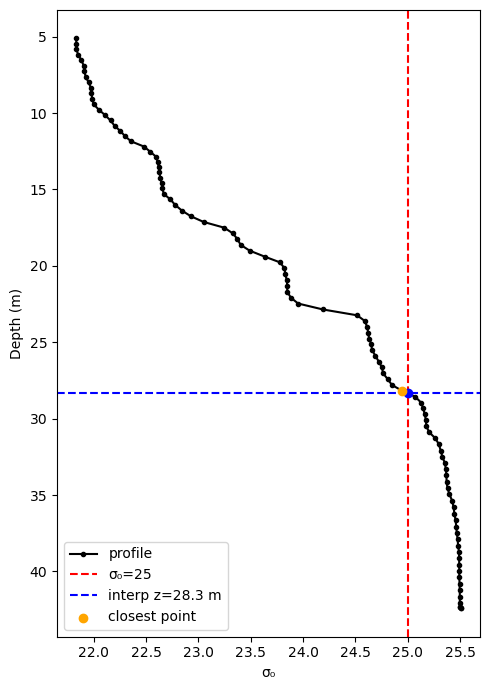

In [ ]:
cruise = '2025-Jan-Pilot'
transect_name = 'sakumono'
OMIPATH_temp = '/mnt/h/Shared drives/OMI Share'
wkdir = f"{OMIPATH_temp}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
ctd_files = glob.glob(wkdir + '*ctd.nc')
datasets = [xr.open_dataset(f) for f in ctd_files]

sigma, depth, z_iso = debug_isopycnal_crossing(datasets[-10], target_sigma=25)

In [ ]:
# here's a version for a specific transect
cruises = [
    '2025-Jan-Pilot',
    '2025-April',
    '2025-Summer',
    '2025-November',
    '2025-December'
]

transect = ['sakumono']

target_sigmas = np.arange(24, 26.25, 0.25)

results = {
    sigma: {
        "mean": [],
        "std": [],
        "median": [],
        "q25": [],
        "q75": [],
        "n": []
    }
    for sigma in target_sigmas
}

OMIPATH_temp = '/mnt/h/Shared drives/OMI Share'
for cruise in cruises:
    path = Path(f"{OMIPATH_temp}/Coastal Measurements/{cruise}/EcoCTD/data/{transect}/Level2/")

    for sigma in target_sigmas:
        z_mean, z_std, z_median, z_q25, z_q75, n = mean_isopycnal_depth_by_cruise(transect, cruise, sigma)
        results[sigma]["mean"].append(z_mean)
        results[sigma]["std"].append(z_std)
        results[sigma]["median"].append(z_median)
        results[sigma]["q25"].append(z_q25)
        results[sigma]["q75"].append(z_q75)
        results[sigma]["n"].append(n)

#debug
print(sigma, results[25]["mean"])

26.0 [107.88963372194205, 112.68775598425478, 60.712803151415244, 103.2108159607781, 97.20610229265847]


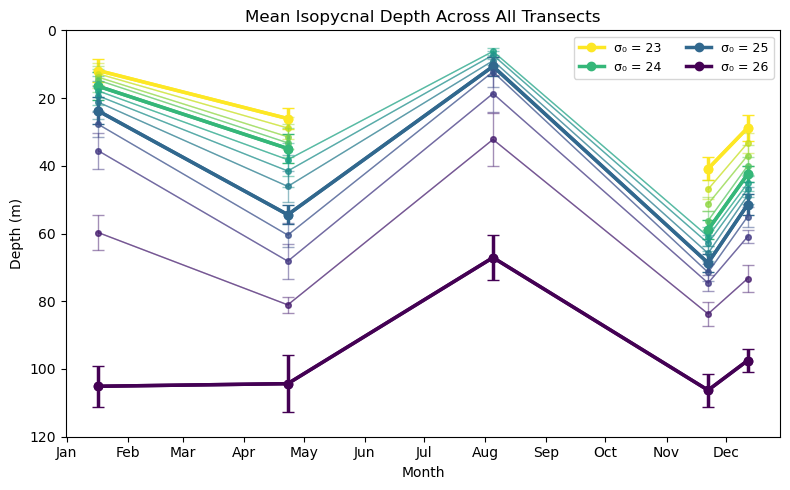

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

# x = np.arange(len(cruises))

cmap = plt.get_cmap('viridis_r')
norm = mcolors.Normalize(vmin=target_sigmas.min(), vmax=target_sigmas.max())

# cruise dates for Sakumono
cruise_dates = pd.to_datetime([
    "2025-01-17",
    "2025-04-23",
    "2025-08-05",
    "2025-11-22",
    "2025-12-12"
])

x = cruise_dates

for sigma in target_sigmas:

    color = cmap(norm(sigma))

    if np.isclose(sigma % 1, 0):
        label = f'σ₀ = {int(sigma)}'
        linewidth = 2.5
        alpha = 1.0
        markersize = 6
    else:
        label = None
        linewidth = 1.0
        alpha = 0.5
        markersize = 4

    mean = np.asarray(results[sigma]["mean"], dtype=float)
    std  = np.asarray(results[sigma]["std"], dtype=float)

    ax.plot(
        x,
        mean,
        marker='o',
        linewidth=linewidth,
        markersize=markersize,
        color=color,
        alpha=alpha,
        label=label
    )

    ax.errorbar(
        x,
        mean,
        yerr=std,
        fmt='o-',              # marker + line
        linewidth=linewidth,
        markersize=markersize,
        color=color,
        alpha=alpha,
        capsize=4,             # little horizontal caps
        label=''
    )

# ax.set_xticks(x)
# ax.set_xticklabels(['Jan', 'Apr', 'Aug', 'Nov', 'Dec'])
import matplotlib.dates as mdates

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax.set_ylabel("Depth (m)")
ax.set_xlabel("Month")
ax.set_title("Mean Isopycnal Depth Across All Transects")

ax.set_ylim(0, 120)
ax.invert_yaxis()
ax.legend(ncol=2, fontsize=9)

# plt.grid()
plt.tight_layout()
plt.show()

In [6]:
# save results as a dataframe I can load later

rows = []

for i, cruise in enumerate(cruises):
    for sigma in target_sigmas:
        rows.append({
            "cruise": cruise,
            "sigma": sigma,
            "mean": results[sigma]["mean"][i],
            "std": results[sigma]["std"][i],
            "median": results[sigma]["median"][i],
            "q25": results[sigma]["q25"][i],
            "q75": results[sigma]["q75"][i],
            "n": results[sigma]["n"][i],
        })

df = pd.DataFrame(rows)
df.to_csv("isopycnal_results_from_23.csv", index=False)

# how to load later:
# df = pd.read_csv("isopycnal_results.csv")

df

,cruise,sigma,mean,std,median,q25,q75,n
0,2025-Jan-Pilot,23.00,11.868369,3.285776,10.735358,9.612686,13.582203,160
1,2025-Jan-Pilot,23.25,12.844159,3.193977,11.562912,10.639274,14.068161,183
2,2025-Jan-Pilot,23.50,13.840502,3.315865,12.728333,11.711520,15.166009,183
3,2025-Jan-Pilot,23.75,14.730272,3.333095,13.815977,12.737235,16.468201,183
4,2025-Jan-Pilot,24.00,16.520839,4.135549,15.042183,13.599174,18.627070,183
...,...,...,...,...,...,...,...,...
60,2025-December,25.00,51.490494,3.108001,52.610839,48.878946,54.190902,56
61,2025-December,25.25,55.025181,2.960505,55.534549,52.616216,57.261701,51
62,2025-December,25.50,60.954434,1.958220,61.242572,60.055332,62.301089,40
63,2025-December,25.75,73.334744,3.950387,74.131440,70.068386,76.314411,32


### Mean isopycnal depth (from Argo)

In [ ]:
def mean_isopycnal_depth_argo(ds, target_sigma):

    iso_depths = []

    time_vals = ds["TIME"].values

    for i in range(len(time_vals)):

        p = ds["PRES"].isel(TIME=i).values
        t = ds["TEMP"].isel(TIME=i).values
        sp = ds["PSAL"].isel(TIME=i).values

        lat = ds["LATITUDE"].isel(TIME=i).values
        lon = ds["LONGITUDE"].isel(TIME=i).values

        mask = np.isfinite(p) & np.isfinite(t) & np.isfinite(sp) & (p > 10)
        if not np.any(mask):
            continue

        p, t, sp = p[mask], t[mask], sp[mask]

        # Convert SP → SA
        sa = gsw.SA_from_SP(sp, p, lon, lat)

        # potential temperature
        pt = gsw.pt_from_t(sa, t, p, 0)

        mask2 = np.isfinite(pt)
        sa, pt, p = sa[mask2], pt[mask2], p[mask2]

        depth = -gsw.z_from_p(p, lat)   # positive downward
        sigma = gsw.sigma0(sa, pt)

        if (sigma.min() <= target_sigma) and (sigma.max() >= target_sigma):

            sort_idx = np.argsort(sigma)
            sigma_sorted = sigma[sort_idx]
            depth_sorted = depth[sort_idx]

            z_iso = np.interp(
                target_sigma,
                sigma_sorted,
                depth_sorted
            )

            iso_depths.append(z_iso)

    if len(iso_depths) == 0:
        return np.nan

    return np.nanmean(iso_depths)

In [ ]:
def isopycnal_depths_argo(ds, target_sigmas):

    time_vals = ds["TIME"].values
    n_time = len(time_vals)
    n_sigma = len(target_sigmas)

    z_iso_all = np.full((n_time, n_sigma), np.nan)

    for i in range(n_time):

        p = ds["PRES"].isel(TIME=i).values
        t = ds["TEMP"].isel(TIME=i).values
        sp = ds["PSAL"].isel(TIME=i).values

        lat = ds["LATITUDE"].isel(TIME=i).values
        lon = ds["LONGITUDE"].isel(TIME=i).values

        mask = np.isfinite(p) & np.isfinite(t) & np.isfinite(sp) & (p > 10)
        if not np.any(mask):
            continue

        p, t, sp = p[mask], t[mask], sp[mask]

        sa = gsw.SA_from_SP(sp, p, lon, lat)
        ct = gsw.CT_from_t(sa, t, p)

        sigma = gsw.sigma0(sa, ct)
        depth = -gsw.z_from_p(p, lat)

        # sort once per profile
        sort_idx = np.argsort(sigma)
        sigma_sorted = sigma[sort_idx]
        depth_sorted = depth[sort_idx]

        for j, target_sigma in enumerate(target_sigmas):

            if sigma_sorted.min() <= target_sigma <= sigma_sorted.max():

                z_iso_all[i, j] = np.interp(
                    target_sigma,
                    sigma_sorted,
                    depth_sorted
                )

    return time_vals, z_iso_all

In [ ]:
wkdir = f"{os.environ['WINPATH']}/OneDrive - Massachusetts Institute of Technology/mit-whoi/gulf_of_guinea/argo/"
argo = glob.glob(wkdir + '*.nc')
argo_datasets = [xr.open_dataset(f) for f in argo]

In [ ]:
argo_datasets[0]

<xarray.Dataset> Size: 34MB
Dimensions:              (TIME: 378, DEPTH: 1022)
Coordinates:
  * TIME                 (TIME) datetime64[ns] 3kB 2021-03-24T20:25:00 ... 20...
    LATITUDE             (TIME) float32 2kB ...
    LONGITUDE            (TIME) float32 2kB ...
    TRAJECTORY           |S7 7B ...
    PRES                 (TIME, DEPTH) float32 2MB ...
Dimensions without coordinates: DEPTH
Data variables: (12/22)
    TIME_QC              (TIME) float32 2kB ...
    POSITION_QC          (TIME) float32 2kB ...
    DC_REFERENCE         (TIME) object 3kB ...
    DIRECTION            (TIME) object 3kB ...
    PRES_QC              (TIME, DEPTH) float32 2MB ...
    PRES_ADJUSTED        (TIME, DEPTH) float32 2MB ...
    ...                   ...
    PSAL_QC              (TIME, DEPTH) float32 2MB ...
    PSAL_ADJUSTED        (TIME, DEPTH) float32 2MB ...
    PSAL_ADJUSTED_QC     (TIME, DEPTH) float32 2MB ...
    PSAL_ADJUSTED_DM     (TIME, DEPTH) object 3MB ...
    PSAL_ADJUSTED_ERROR  (TIME, DEPTH) float32 2MB ...
    PRES_CORE            (TIME, DEPTH) float32 2MB ...
Attributes: (12/52)
    platform_code:                  6903053
    platform_name:                  ARVOR Profiling Float
    wmo_platform_code:              6903053
    ices_platform_code:              
    coriolis_platform_code:         6903053
    comment:                         
    ...                             ...
    date_modified:                  2026-03-05T16:14:35Z
    history:                        2026-03-05T16:14:35Z : Creation
    publisher_email:                cmems-service@ifremer.fr
    publisher_name:                 Copernicus Marine Service
    publisher_url:                  https://marine.copernicus.eu/ http://www....
    publisher_institution:          Ifremer

In [ ]:
target_sigmas = np.arange(24, 27, 0.25)

time_vals, z_iso_all = isopycnal_depths_argo(
    argo_datasets[0],
    target_sigmas
)

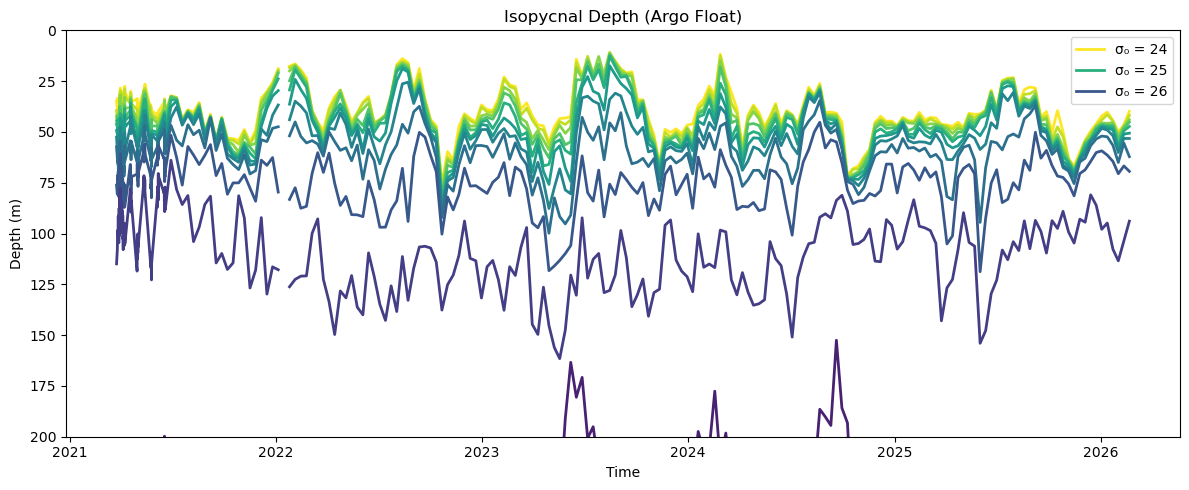

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

cmap = plt.get_cmap('viridis_r')
norm = mcolors.Normalize(vmin=target_sigmas.min(), vmax=target_sigmas.max())

for j, sigma in enumerate(target_sigmas):

    color = cmap(norm(sigma))

    if np.isclose(sigma % 1, 0):
        label = f'σ₀ = {int(sigma)}'
    else:
        label = None

    ax.plot(
        time_vals,
        z_iso_all[:, j],
        linewidth=2,
        color=color,
        label=label
    )

ax.set_ylabel("Depth (m)")
ax.set_xlabel("Time")
ax.set_title("Isopycnal Depth (Argo Float)")

ax.set_ylim([0, 200])

ax.invert_yaxis()
ax.legend()

plt.tight_layout()
plt.show()

### (5) plot mean profiles of physical variables 

##### plot the average profile for a single cruise

In [ ]:
# '2025-Jan-Pilot', '2025-April', '2025-Summer'
cruise = '2025-Summer'

# prampram, ayitepa, sakumono, jamestown
transect_name = 'shakedown'
data_type = 'ctd'

wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
data = glob.glob(wkdir + '*' + data_type + '.nc')

datasets = [xr.open_dataset(f) for f in data]

/tmp/ipykernel_1703/964509266.py:27: RuntimeWarning: Mean of empty slice
  CT_mean = np.nanmean(CT_interp, axis=0)
/tmp/ipykernel_1703/964509266.py:30: RuntimeWarning: Mean of empty slice
  SA_mean = np.nanmean(SA_interp, axis=0)
/tmp/ipykernel_1703/964509266.py:33: RuntimeWarning: Mean of empty slice
  sigma_mean = np.nanmean(sigma_interp, axis=0)


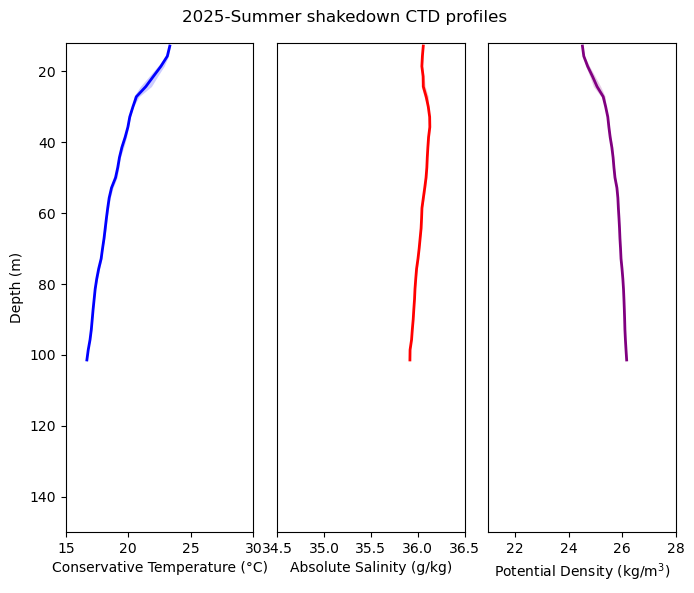

In [ ]:
max_depth = 150
depth_grid = np.linspace(10, max_depth, 50)  # Define a common depth grid

# Initialize arrays to store interpolated values
CT_interp = np.full((len(datasets), len(depth_grid)), np.nan)
SA_interp = np.full((len(datasets), len(depth_grid)), np.nan)
sigma_interp = np.full((len(datasets), len(depth_grid)), np.nan)

# Interpolate each profile onto the common depth grid
for i, ds in enumerate(datasets):
    p = ds["P"].values
    ct = ds["CT"].values
    sa = ds["SA"].values
    
    p = interpolate_nans(p, np.arange(len(p)))
    ct = interpolate_nans(ct, np.arange(len(ct)))
    sa = interpolate_nans(sa, np.arange(len(sa)))
    
    # Interpolate to the common depth grid
    CT_interp[i, :] = np.interp(depth_grid, p, ct, left=np.nan, right=np.nan)
    SA_interp[i, :] = np.interp(depth_grid, p, sa, left=np.nan, right=np.nan)

    # compute protential density for each profile
    sigma_interp[i, :] = gsw.density.sigma0(SA_interp[i, :], CT_interp[i, :])

# Compute the mean profile and std
CT_mean = np.nanmean(CT_interp, axis=0)
CT_std  = np.nanstd(CT_interp, axis=0)

SA_mean = np.nanmean(SA_interp, axis=0)
SA_std  = np.nanstd(SA_interp, axis=0)

sigma_mean = np.nanmean(sigma_interp, axis=0)
sigma_std  = np.nanstd(sigma_interp, axis=0)

# Compute buoyancy frequency N^2 using the mean profiles
# N2_mean, p_mid = gsw.Nsquared(SA_mean, CT_mean, depth_grid)

# Create figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7, 6))

# # Plot individual profiles
# for ds in datasets:
#     p = ds["P"].values
#     ct = ds["CT"].values
#     sa = ds["SA"].values
    
#     p = interpolate_nans(p, np.arange(len(p)))
#     ct = interpolate_nans(ct, np.arange(len(ct)))
#     sa = interpolate_nans(sa, np.arange(len(sa)))
    
#     sigma = gsw.density.sigma0(sa, ct)
    
#     ax1.plot(ct, p, 'b', linewidth=0.5, alpha=0.25)
#     ax2.plot(sa, p, 'r', linewidth=0.5, alpha=0.25)
#     ax3.plot(sigma, p, 'purple', linewidth=0.5, alpha=0.25)

# Plot mean profiles with variance
ax1.plot(CT_mean, depth_grid, 'b', linewidth=2, label="Mean")
ax1.fill_betweenx(depth_grid, CT_mean - CT_std, CT_mean + CT_std, color='b', alpha=0.2, linewidth=0)

ax2.plot(SA_mean, depth_grid, 'r', linewidth=2, label="Mean")
ax2.fill_betweenx(depth_grid, SA_mean - SA_std, SA_mean + SA_std, color='r', alpha=0.2, linewidth=0)

ax3.plot(sigma_mean, depth_grid, 'purple', linewidth=2, label="Mean")
ax3.fill_betweenx(depth_grid, sigma_mean - sigma_std, sigma_mean + sigma_std, color='purple', alpha=0.2, linewidth=0)

# ax4.plot(N2_mean, p_mid, 'k', linewidth=2, label="Mean")

# Formatting axes
ax1.set_ylabel('Depth (m)') # 'Pressure (dbar)'
ax1.set_xlabel('Conservative Temperature (°C)')
ax1.set_ylim(12, max_depth)
ax1.set_xlim(15, 30)

ax2.set_xlabel('Absolute Salinity (g/kg)')
ax2.set_yticks([])
ax2.set_ylim(12, max_depth)
ax2.set_xlim(34.5, 36.5)

ax3.set_xlabel('Potential Density (kg/m$^3$)')
ax3.set_yticks([])
ax3.set_ylim(12, max_depth)
ax3.set_xlim(21, 28)

# ax4.set_xlabel('Average N$^2$')
# ax4.set_yticks([])
# ax4.set_ylim(12, max_depth)
# ax4.set_xlim(0, 0.005)

ax1.invert_yaxis()
ax2.invert_yaxis()
ax3.invert_yaxis()
# ax4.invert_yaxis()

# plt.legend()
fig.suptitle(f"{cruise} {transect_name} CTD profiles")
plt.tight_layout()
plt.show()


In [ ]:
filename = f"2025_Jan_Apr_{transect_name}_avg_profiles.png"
fig.savefig(os.path.join(os.getcwd(),'figures', filename))

##### plot the avg profiles by density

In [ ]:
def plot_mean_profiles_density(ax1, ax2, ax3, cruise, transect_name, linestyle='-', label=None):
    wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
    data = glob.glob(wkdir + '*ctd.nc')
    datasets = [xr.open_dataset(f) for f in data]

    sigma_grid = np.linspace(20, 27, 50)  # example range for sigma0

    CT_interp = np.full((len(datasets), len(sigma_grid)), np.nan)
    SA_interp = np.full((len(datasets), len(sigma_grid)), np.nan)
    chl_interp = np.full((len(datasets), len(sigma_grid)), np.nan)

    for i, ds in enumerate(datasets):
        p = interpolate_nans(ds["P"].values, np.arange(len(ds["P"])))
        ct = interpolate_nans(ds["CT"].values, np.arange(len(ds["CT"])))
        sa = interpolate_nans(ds["SA"].values, np.arange(len(ds["SA"])))

        sigma = gsw.density.sigma0(sa, ct)

        CT_interp[i, :] = np.interp(sigma_grid, sigma, ct, left=np.nan, right=np.nan)
        SA_interp[i, :] = np.interp(sigma_grid, sigma, sa, left=np.nan, right=np.nan)

    # Do the same for chl
    data_fls = glob.glob(wkdir + '*fls.nc')
    datasets_fls = [xr.open_dataset(f) for f in data_fls]

    for i, ds in enumerate(datasets_fls):
        p = interpolate_nans(ds["P"].values, np.arange(len(ds["P"])))
        chl = interpolate_nans(ds["chl_cal"].values, np.arange(len(ds["chl_cal"])))

        chl_interp[i, :] = np.interp(sigma_grid, sigma, chl, left=np.nan, right=np.nan)
        

    CT_mean = np.nanmean(CT_interp, axis=0)
    CT_std  = np.nanstd(CT_interp, axis=0)
    SA_mean = np.nanmean(SA_interp, axis=0)
    SA_std  = np.nanstd(SA_interp, axis=0)

    chl_mean = np.nanmean(chl_interp, axis=0)
    chl_std  = np.nanstd(chl_interp, axis=0)

    # Plot
    ax1.plot(CT_mean, sigma_grid, 'b', linestyle=linestyle, linewidth=2)
    ax1.fill_betweenx(sigma_grid, CT_mean - CT_std, CT_mean + CT_std, color='b', alpha=0.2)

    ax2.plot(SA_mean, sigma_grid, 'r', linestyle=linestyle, linewidth=2)
    ax2.fill_betweenx(sigma_grid, SA_mean - SA_std, SA_mean + SA_std, color='r', alpha=0.2)

    ax3.plot(chl_mean, sigma_grid, 'g', linestyle=linestyle, linewidth=2)
    ax3.fill_betweenx(sigma_grid, chl_mean - chl_std, chl_mean + chl_std, color='g', alpha=0.2)



In [ ]:
def plot_mean_profiles_density(ax1, ax2, ax3, cruise, transect_name, linestyle='-', label=None):
    wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
    data_ctd = sorted(glob.glob(wkdir + '*ctd.nc'))
    data_fls = sorted(glob.glob(wkdir + '*fls.nc'))

    assert len(data_ctd) == len(data_fls), "CTD and FLS files must be 1-to-1 matched"

    sigma_grid = np.linspace(20, 27, 50)

    CT_interp = np.full((len(data_ctd), len(sigma_grid)), np.nan)
    SA_interp = np.full((len(data_ctd), len(sigma_grid)), np.nan)
    chl_interp = np.full((len(data_ctd), len(sigma_grid)), np.nan)

    for i, (f_ctd, f_fls) in enumerate(zip(data_ctd, data_fls)):
        ds_ctd = xr.open_dataset(f_ctd)
        ds_fls = xr.open_dataset(f_fls)

        # Interpolate P, CT, SA from CTD
        p_ctd = interpolate_nans(ds_ctd["P"].values, np.arange(len(ds_ctd["P"])))
        ct = interpolate_nans(ds_ctd["CT"].values, np.arange(len(ds_ctd["CT"])))
        sa = interpolate_nans(ds_ctd["SA"].values, np.arange(len(ds_ctd["SA"])))

        # Use a common pressure grid
        p_grid = np.linspace(np.nanmin(p_ctd), np.nanmax(p_ctd), len(p_ctd))
        ct_i = np.interp(p_grid, p_ctd, ct)
        sa_i = np.interp(p_grid, p_ctd, sa)

        sigma = gsw.density.sigma0(sa_i, ct_i)

        CT_interp[i, :] = np.interp(sigma_grid, sigma, ct_i, left=np.nan, right=np.nan)
        SA_interp[i, :] = np.interp(sigma_grid, sigma, sa_i, left=np.nan, right=np.nan)

        # Interpolate chl to same p_grid, then to sigma
        p_fls = interpolate_nans(ds_fls["P"].values, np.arange(len(ds_fls["P"])))
        chl = interpolate_nans(ds_fls["chl_cal"].values, np.arange(len(ds_fls["chl_cal"])))
        chl_i = np.interp(p_grid, p_fls, chl)

        chl_interp[i, :] = np.interp(sigma_grid, sigma, chl_i, left=np.nan, right=np.nan)

    # Calculate mean and std
    CT_mean, CT_std = np.nanmean(CT_interp, axis=0), np.nanstd(CT_interp, axis=0)
    SA_mean, SA_std = np.nanmean(SA_interp, axis=0), np.nanstd(SA_interp, axis=0)
    chl_mean, chl_std = np.nanmean(chl_interp, axis=0), np.nanstd(chl_interp, axis=0)

    # Plot
    ax1.plot(CT_mean, sigma_grid, 'b', linestyle=linestyle, linewidth=2)
    ax1.fill_betweenx(sigma_grid, CT_mean - CT_std, CT_mean + CT_std, color='b', alpha=0.2)

    ax2.plot(SA_mean, sigma_grid, 'r', linestyle=linestyle, linewidth=2)
    ax2.fill_betweenx(sigma_grid, SA_mean - SA_std, SA_mean + SA_std, color='r', alpha=0.2)

    ax3.plot(chl_mean, sigma_grid, 'g', linestyle=linestyle, linewidth=2)
    ax3.fill_betweenx(sigma_grid, chl_mean - chl_std, chl_mean + chl_std, color='g', alpha=0.2)


<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_501452/838579568.py:19: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$\sigma$ (kg/m$^3$)') # 'Pressure (dbar)', 'Depth (m)'
/tmp/ipykernel_501452/838579568.py:19: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$\sigma$ (kg/m$^3$)') # 'Pressure (dbar)', 'Depth (m)'


TypeError: plot_mean_profiles() missing 2 required positional arguments: 'transect_name' and 'max_depth'

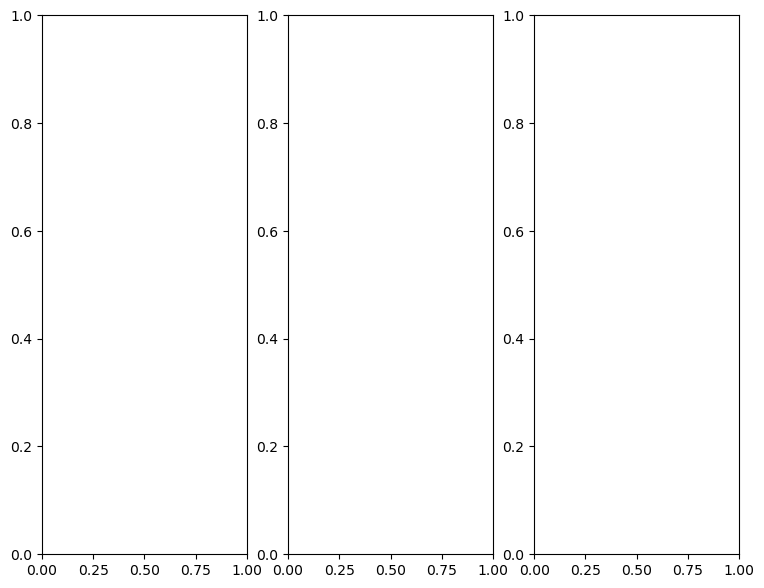

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 7))


cruises = ['2025-Jan-Pilot', '2025-April', '2025-Summer', '2025-November']
# ls = ['--', '-', '-.', ':']
colors = ["" "#AA1b59", "#274cbe", "#6b30bf", "#347a7a"]

transect_name = 'Sakumono'

for cruise, color in zip(cruises, colors):
    plot_mean_profiles(ax1, ax2, ax3, cruise, transect_name, color=color, label=cruise)

# Axis labels/limits
for ax in [ax1, ax2, ax3]:
    # ax.set_ylim(12, max_depth)
    ax.invert_yaxis()
    # ax.legend()

ax1.set_ylabel('$\sigma$ (kg/m$^3$)') # 'Pressure (dbar)', 'Depth (m)'
ax1.set_xlabel('Conservative Temperature (°C)')
ax1.set_xlim(15, 30)

ax2.set_xlabel('Absolute Salinity (g/kg)')
ax2.set_yticks([])
ax2.set_xlim(34.5, 36.5)

ax3.set_xlabel('Chlorophyll-a (mg m$^{-3}$)')
ax3.set_yticks([])
ax3.set_xlim(0, 1.5)

fig.suptitle(f"Mean Profiles at {transect_name}")
plt.tight_layout()
plt.show()

#### compute mean profiles and save to .nc for oceananigans model

In [ ]:
def compute_mean_profiles(cruise, transect_name, max_depth):
    wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
    data = glob.glob(wkdir + '*ctd.nc')
    datasets = [xr.open_dataset(f) for f in data]

    depth_grid = np.linspace(10, max_depth, 50)

    CT_interp = np.full((len(datasets), len(depth_grid)), np.nan)
    SA_interp = np.full((len(datasets), len(depth_grid)), np.nan)
    sigma_interp = np.full((len(datasets), len(depth_grid)), np.nan)
    buoyancy_interp = np.full((len(datasets), len(depth_grid)), np.nan)

    g = 9.81
    rho0 = 1025  # reference density in kg/m³

    for i, ds in enumerate(datasets):
        p = interpolate_nans(ds["P"].values, np.arange(len(ds["P"])))
        ct = interpolate_nans(ds["CT"].values, np.arange(len(ds["CT"])))
        sa = interpolate_nans(ds["SA"].values, np.arange(len(ds["SA"])))

        CT_interp[i, :] = np.interp(depth_grid, p, ct, left=np.nan, right=np.nan)
        SA_interp[i, :] = np.interp(depth_grid, p, sa, left=np.nan, right=np.nan)
        sigma_interp[i, :] = gsw.density.sigma0(SA_interp[i, :], CT_interp[i, :])

        rho = gsw.density.rho(SA_interp[i, :], CT_interp[i, :], depth_grid)

        buoyancy_interp[i, :] = -g * (rho - rho0) / rho0
    
    # for chlorophyll, we need to load the fls datasets
    data = glob.glob(wkdir + '*fls.nc')
    datasets = [xr.open_dataset(f) for f in data]

    chl_interp = np.full((len(datasets), len(depth_grid)), np.nan)

    for i, ds in enumerate(datasets):
        p = interpolate_nans(ds["P"].values, np.arange(len(ds["P"])))
        chl = interpolate_nans(ds["chl_cal"].values, np.arange(len(ds["chl_cal"])))

        chl_interp[i, :] = np.interp(depth_grid, p, chl, left=np.nan, right=np.nan)

    return {
        "depth": depth_grid,
        "CT_mean": np.nanmean(CT_interp, axis=0),
        "CT_std":  np.nanstd(CT_interp, axis=0),
        "SA_mean": np.nanmean(SA_interp, axis=0),
        "SA_std":  np.nanstd(SA_interp, axis=0),
        "sigma_mean": np.nanmean(sigma_interp, axis=0),
        "sigma_std":  np.nanstd(sigma_interp, axis=0),
        "buoyancy_mean": np.nanmean(buoyancy_interp, axis=0),
        "buoyancy_std":  np.nanstd(buoyancy_interp, axis=0),
        "chl_mean": np.nanmean(chl_interp, axis=0),
        "chl_std" : np.nanstd(chl_interp, axis=0)
    }


In [ ]:
def save_all_profiles_to_nc(all_profiles, cruises, transect_name, outpath="transect_profiles.nc"):
    depth = all_profiles[0]["depth"]

    ds = xr.Dataset(
        data_vars=dict(
            CT_mean=(["cruise", "depth"], np.vstack([p["CT_mean"] for p in all_profiles])),
            CT_std =( ["cruise", "depth"], np.vstack([p["CT_std"]  for p in all_profiles])),
            SA_mean=(["cruise", "depth"], np.vstack([p["SA_mean"] for p in all_profiles])),
            SA_std =( ["cruise", "depth"], np.vstack([p["SA_std"]  for p in all_profiles])),
            b_mean=(["cruise", "depth"], np.vstack([p["buoyancy_mean"] for p in all_profiles])),
            b_std =( ["cruise", "depth"], np.vstack([p["buoyancy_std"]  for p in all_profiles])),
            sigma_mean=(["cruise", "depth"], np.vstack([p["sigma_mean"] for p in all_profiles])),
            sigma_std =( ["cruise", "depth"], np.vstack([p["sigma_std"]  for p in all_profiles])),
            chl_mean=(["cruise", "depth"], np.vstack([p["chl_mean"] for p in all_profiles])),
            chl_std =( ["cruise", "depth"], np.vstack([p["chl_std"]  for p in all_profiles]))
        ),
        coords=dict(
            depth=("depth", depth),
            cruise=("cruise", cruises),
        ),
        attrs=dict(
            description=f"Mean hydrographic profiles for Jan, April and August 2025 cruises on the {transect_name} transect",
            transect=transect_name,
            source="EcoCTD Level2 processing",
        )
    )
    ds.to_netcdf(outpath)
    print(f"Saved {outpath}")


In [ ]:
transect_name = "Sakumono"
cruises = ['2025-Jan-Pilot', '2025-April', '2025-Summer']

all_profiles = []
for cruise in cruises:
    profiles = compute_mean_profiles(cruise, transect_name, max_depth=100)
    all_profiles.append(profiles)

save_all_profiles_to_nc(all_profiles, cruises, transect_name, f"{transect_name}_profiles.nc")

/tmp/ipykernel_156819/1007646486.py:43: RuntimeWarning: Mean of empty slice
  "CT_mean": np.nanmean(CT_interp, axis=0),
/tmp/ipykernel_156819/1007646486.py:45: RuntimeWarning: Mean of empty slice
  "SA_mean": np.nanmean(SA_interp, axis=0),
/tmp/ipykernel_156819/1007646486.py:47: RuntimeWarning: Mean of empty slice
  "sigma_mean": np.nanmean(sigma_interp, axis=0),
/tmp/ipykernel_156819/1007646486.py:49: RuntimeWarning: Mean of empty slice
  "buoyancy_mean": np.nanmean(buoyancy_interp, axis=0),
/tmp/ipykernel_156819/1007646486.py:51: RuntimeWarning: Mean of empty slice
  "chl_mean": np.nanmean(chl_interp, axis=0),


Saved Sakumono_profiles.nc


In [ ]:
ds.close()

In [ ]:
ds = xr.open_dataset("Sakumono_profiles.nc")

In [ ]:
ds.b_mean.sel(cruise='2025-Summer').values

array([        nan, -0.00058514, -0.00156159, -0.00222595, -0.00292896,
       -0.00371446, -0.00448984, -0.00526999, -0.0057862 , -0.00620828,
       -0.00662161, -0.00708463, -0.00755049, -0.00795143, -0.00836696,
       -0.00869589, -0.00897714, -0.00928767, -0.00952196, -0.00974709,
       -0.00999526, -0.01025402, -0.01044975, -0.01071584, -0.01093919,
       -0.01111407, -0.01123559, -0.01138778, -0.01156498, -0.01172209,
       -0.01187873, -0.01203947, -0.01220297, -0.01239579, -0.01262427,
       -0.0128463 , -0.01307316, -0.01324769, -0.01343392, -0.01361366,
       -0.01375995, -0.01398196, -0.01418891, -0.01435293, -0.01454382,
       -0.0146879 , -0.01480122, -0.01493435, -0.01510475, -0.01525913])

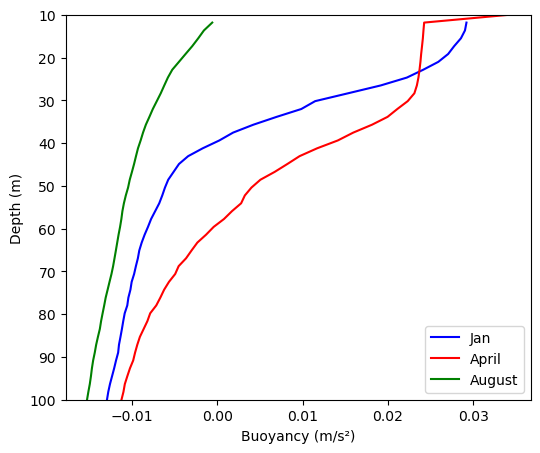

In [ ]:
b1 = ds.b_mean.sel(cruise='2025-Jan-Pilot')
b2 = ds.b_mean.sel(cruise='2025-April')
b3 = ds.b_mean.sel(cruise='2025-Summer')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(b1, ds.depth, 'b', label='Jan')
ax.plot(b2, ds.depth, 'r', label='April')
ax.plot(b3, ds.depth, 'g', label='August')
ax.set_xlabel('Buoyancy (m/s²)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(100, 10)
ax.legend()

#### plot mean profiles by depth

In [153]:
def plot_mean_profiles(ax1, ax2, ax3, ax4, cruise, transect_name, max_depth, color='b', label=None, plot_four='chl'):
    # wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
    OMIPATH_temp = '/mnt/h/Shared drives/OMI Share'
    wkdir = f"{OMIPATH_temp}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
    data = glob.glob(wkdir + '*ctd.nc')
    datasets = [xr.open_dataset(f) for f in data]

    depth_grid = np.linspace(10, max_depth, 50)
    mid_depth_grid = (depth_grid[:-1] + depth_grid[1:]) / 2

    CT_interp = np.full((len(datasets), len(depth_grid)), np.nan)
    SA_interp = np.full((len(datasets), len(depth_grid)), np.nan)
    sigma_interp = np.full((len(datasets), len(depth_grid)), np.nan)
    # buoyancy_interp = np.full((len(datasets), len(depth_grid)), np.nan)
    N2_interp = np.full((len(datasets), len(mid_depth_grid)), np.nan)

    for i, ds in enumerate(datasets):
        p = interpolate_nans(ds["seaPress"].values, np.arange(len(ds["seaPress"])))
        ct = interpolate_nans(ds["CT"].values, np.arange(len(ds["CT"])))
        sa = interpolate_nans(ds["SA"].values, np.arange(len(ds["SA"])))
        
        CT_interp[i, :] = np.interp(depth_grid, p, ct, left=np.nan, right=np.nan)
        SA_interp[i, :] = np.interp(depth_grid, p, sa, left=np.nan, right=np.nan)
        sigma_interp[i, :] = gsw.density.sigma0(SA_interp[i, :], CT_interp[i, :])

        N2, p_mid = gsw.Nsquared(sa, ct, p)

        mask = np.isfinite(N2) & np.isfinite(p_mid)

        if mask.sum() >= 2:
            p_mid_valid = p_mid[mask]
            N2_valid = N2[mask]

            order = np.argsort(p_mid_valid)
            p_mid_valid = p_mid_valid[order]
            N2_valid = N2_valid[order]

            N2_interp[i, :] = np.interp(
                mid_depth_grid,
                p_mid_valid,
                N2_valid,
                left=np.nan,
                right=np.nan
            )

    CT_mean = np.nanmean(CT_interp, axis=0)
    CT_std  = np.nanstd(CT_interp, axis=0)
    SA_mean = np.nanmean(SA_interp, axis=0)
    SA_std  = np.nanstd(SA_interp, axis=0)
    sigma_mean = np.nanmean(sigma_interp, axis=0)
    sigma_std  = np.nanstd(sigma_interp, axis=0)
    
    # for chlorophyll, we need to load the fls datasets
    if plot_four == 'chl':
        data = glob.glob(wkdir + '*fls.nc')
        datasets = [xr.open_dataset(f) for f in data]

        chl_interp = np.full((len(datasets), len(depth_grid)), np.nan)
        for i, ds in enumerate(datasets):
            p = interpolate_nans(ds["seaPress"].values, np.arange(len(ds["seaPress"])))
            chl = interpolate_nans(ds["chl_cal"].values, np.arange(len(ds["chl_cal"])))

            chl_interp[i, :] = np.interp(depth_grid, p, chl, left=np.nan, right=np.nan)

        chl_mean = np.nanmean(chl_interp, axis=0)
        chl_std  = np.nanstd(chl_interp, axis=0)

    # Plot
    ax1.plot(CT_mean, depth_grid, color=color, linestyle='-', linewidth=2, label="Mean")
    ax1.fill_betweenx(depth_grid, CT_mean - CT_std, CT_mean + CT_std, color=color, alpha=0.2, linewidth=0)

    ax2.plot(SA_mean, depth_grid, color=color, linestyle='-', linewidth=2, label="Mean")
    ax2.fill_betweenx(depth_grid, SA_mean - SA_std, SA_mean + SA_std, color=color, alpha=0.2, linewidth=0)

    ax3.plot(sigma_mean, depth_grid, color=color, linestyle='-', linewidth=2, label="Mean")
    ax3.fill_betweenx(depth_grid, sigma_mean - sigma_std, sigma_mean + sigma_std, color=color, alpha=0.2, linewidth=0)
    # ax3.plot(buoyancy_mean, depth_grid, 'purple', linestyle=linestyle, linewidth=2, label="Mean")
    # ax3.fill_betweenx(depth_grid, buoyancy_mean - buoyancy_std, buoyancy_mean + buoyancy_std, color='purple', alpha=0.2, linewidth=0)

    if plot_four == 'chl':
        ax4.plot(chl_mean, depth_grid, color=color, linestyle='-', linewidth=2, label="Chlorophyll Mean")
        ax4.fill_betweenx(depth_grid, chl_mean - chl_std, chl_mean + chl_std, color=color, alpha=0.2, linewidth=0)
    else:
        N2_median = np.nanmedian(N2_interp, axis=0)
        N2_q25 = np.nanpercentile(N2_interp, 25, axis=0)
        N2_q75 = np.nanpercentile(N2_interp, 75, axis=0)
        N2_std  = np.nanstd(N2_interp, axis=0)
        ax4.plot(N2_median, mid_depth_grid, color=color, linestyle='-', linewidth=2, label="N² Median")
        ax4.fill_betweenx(mid_depth_grid, N2_median - N2_q25, N2_median + N2_q75, color=color, alpha=0.2, linewidth=0)


In [5]:
cruise_colors = {
    "2025-Jan-Pilot": ("#ff6b6b", "#b00202"),  # red
    "2025-April": ("#4d91f7", "#082ad5"),     # blue
    "2025-Summer": ("#ffd43b", "#f0b208"),    # yellow
    "2025-November": ("#f18bfa", "#6d0d85"),  # purple
    "2025-December": ("#78e98b", "#2f9e44"),  # green
}


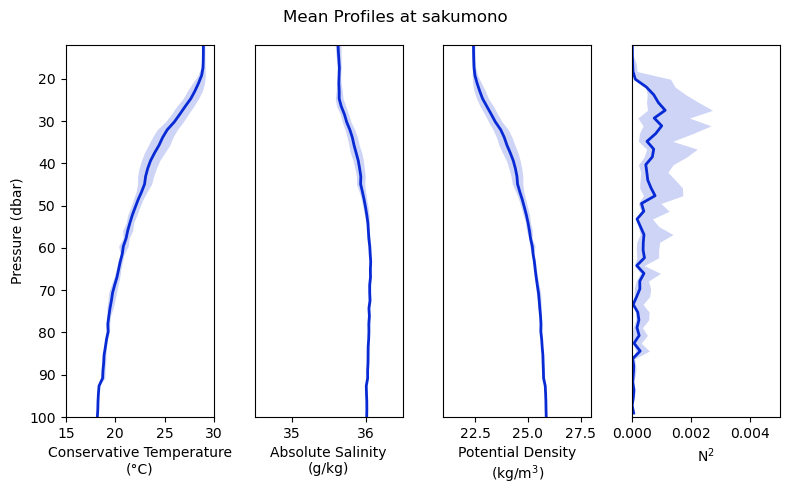

In [154]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(8, 5))

cruises = ['2025-Jan-Pilot', '2025-April', '2025-Summer', '2025-November', '2025-December']
cruise_names = ['January', 'April', 'August', 'November', 'December']

cruises = ['2025-April']
cruise_names = ['April']
# colors = [ "#AA1b59", "#274cbe", "#6b30bf", "#347a7a", "#C5670A"]
colors = [cruise_colors[c][1] for c in cruises]

# ls = ['--', '-', '-.', ':']

# just looking at April 2025 v. 2026
# cruises = ['2025-April', '2026-April']
# colors = [ "#4f7bff", "#274cbe"]

color = []
transect_name = 'sakumono'
max_depth = 100

plot_four = 'N2'  # or 'chl' for chlorophyll

for cruise, color in zip(cruises, colors):
    plot_mean_profiles(ax1, ax2, ax3, ax4, cruise, transect_name, max_depth, color=color, label=cruise_names[cruises.index(cruise)], plot_four=plot_four)

# Axis labels/limits
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_ylim(12, max_depth)
    ax.invert_yaxis()
    # ax.legend()

ax1.set_ylabel('Pressure (dbar)') # 'Pressure (dbar)'
ax1.set_xlabel('Conservative Temperature\n(°C)')
ax1.set_xlim(15, 30)

ax2.set_xlabel('Absolute Salinity\n(g/kg)')
ax2.set_yticks([])
ax2.set_xlim(34.5, 36.5)

ax3.set_xlabel('Potential Density\n(kg/m$^3$)')
ax3.set_yticks([])
ax3.set_xlim(21, 28)

if plot_four == 'chl':
    ax4.set_xlabel('Chlorophyll-a\n(mg m$^{-3}$)')
    ax4.set_yticks([])
    ax4.set_xlim(0, 1.5)
else:
    ax4.set_yticks([])
    ax4.set_xlabel('N$^2$')
    ax4.set_xlim(0, 0.005)


fig.suptitle(f"Mean Profiles at {transect_name}")
plt.tight_layout()
plt.show()


#### isopycnal depth focused plots 

In [ ]:
def plot_density_profiles(ax, cruise, transect_name, max_depth, color='b', label=None):
    # wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
    OMIPATH_temp = '/mnt/h/Shared drives/OMI Share'
    wkdir = f"{OMIPATH_temp}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
    data = glob.glob(wkdir + '*ctd.nc')
    datasets = [xr.open_dataset(f) for f in data]

    if label is None:
        label = cruise

    depth_grid = np.linspace(5, max_depth, 50)

    sigma_interp = np.full((len(datasets), len(depth_grid)), np.nan)

    for i, ds in enumerate(datasets):
        p = interpolate_nans(ds["seaPress"].values, np.arange(len(ds["seaPress"])))
        ct = interpolate_nans(ds["CT"].values, np.arange(len(ds["CT"])))
        sa = interpolate_nans(ds["SA"].values, np.arange(len(ds["SA"])))
        
        CT_interp = np.interp(depth_grid, p, ct, left=np.nan, right=np.nan)
        SA_interp = np.interp(depth_grid, p, sa, left=np.nan, right=np.nan)
        sigma_interp[i, :] = gsw.density.sigma0(SA_interp, CT_interp)

    sigma_mean = np.nanmean(sigma_interp, axis=0)
    sigma_std  = np.nanstd(sigma_interp, axis=0)
    
    ax.plot(sigma_mean, depth_grid, color=color, linestyle='-', linewidth=2, label=label)
    ax.fill_betweenx(depth_grid, sigma_mean - sigma_std, sigma_mean + sigma_std, color=color, alpha=0.2, linewidth=0)


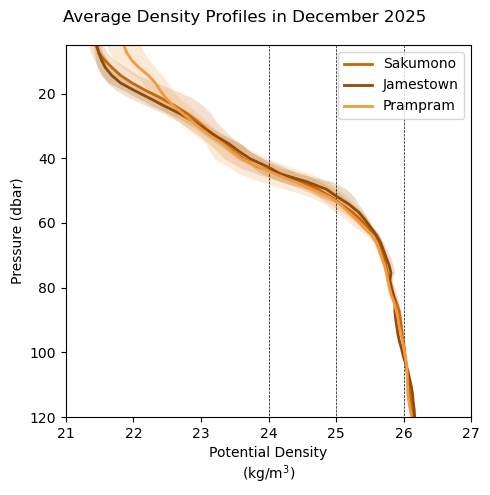

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.vlines(x=26, ymin=5, ymax=max_depth, color='k', linestyle='--', linewidth=0.5)
ax.vlines(x=25, ymin=5, ymax=max_depth, color='k', linestyle='--', linewidth=0.5)
ax.vlines(x=24, ymin=5, ymax=max_depth, color='k', linestyle='--', linewidth=0.5)

# ax.hlines(y=60, xmin=21, xmax=27, color='k', linestyle='--', linewidth=0.5)
# ax.hlines(y=40, xmin=21, xmax=27, color='k', linestyle='--', linewidth=0.5)
# ax.hlines(y=20, xmin=21, xmax=27, color='k', linestyle='--', linewidth=0.5)

cruises = ['2025-Jan-Pilot', '2025-April', '2025-Summer', '2025-November', '2025-December']
cruise_names = ['January', 'April', 'August', 'November', 'December']
colors = [ "#AA1b59", "#274cbe", "#6b30bf", "#347a7a", "#C5670A"]

# ls = ['--', '-', '-.', ':']

# just looking at April 2025 v. 2026
# cruises = ['2025-April', '2026-April']
# colors = [ "#4f7bff", "#274cbe"]

# just looking at December
cruises = ['2025-December']
colors = [ "#C5670A", "#914B06","#F39A41"]

color = []
transect_name = ['sakumono', 'jamestown', 'prampram']
max_depth = 120

# for cruise, color in zip(cruises, colors):
#     plot_density_profiles(ax, cruise, transect_name, max_depth, color=color, label=cruise_names[cruises.index(cruise)])

for transect, color in zip(transect_name, colors):
    plot_density_profiles(ax, cruise, transect, max_depth, color=color, label=transect.capitalize())

# Axis labels/limits
ax.set_ylim(5, max_depth)
ax.invert_yaxis()

ax.set_xlabel('Potential Density\n(kg/m$^3$)')
ax.set_ylabel('Pressure (dbar)')
ax.set_xlim(21, 27)


# fig.suptitle(f"Average Profiles at {transect_name}")
fig.suptitle(f"Average Density Profiles in December 2025")
# plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


In [162]:
# filename = f"{transect_name}_average_profiles.png"
filename = f"all_transects_median_profiles_N2.svg"
fig.savefig(os.path.join(os.getcwd(),'figures', filename))

#### mean profiles for ALL transects

In [6]:
cruise_colors = {
    "2025-Jan-Pilot": ("#ff6b6b", "#b00202"),  # red
    "2025-April": ("#4d91f7", "#082ad5"),     # blue
    "2025-Summer": ("#ffd43b", "#f0b208"),    # yellow
    "2025-November": ("#f18bfa", "#6d0d85"),  # purple
    "2025-December": ("#78e98b", "#2f9e44"),  # green
}

In [2]:
def interp_N2_from_files(files, pressure_grid):
    mid_pressure_grid = (pressure_grid[:-1] + pressure_grid[1:]) / 2
    out = np.full((len(files), len(mid_pressure_grid)), np.nan)

    for i, f in enumerate(files):
        with xr.open_dataset(f) as ds:
            p = interpolate_nans(ds["seaPress"].values, np.arange(len(ds["seaPress"])))
            ct = interpolate_nans(ds["CT"].values, np.arange(len(ds["CT"])))
            sa = interpolate_nans(ds["SA"].values, np.arange(len(ds["SA"])))

            mask = np.isfinite(p) & np.isfinite(ct) & np.isfinite(sa)
            p = p[mask]
            ct = ct[mask]
            sa = sa[mask]

            if len(p) < 3:
                continue

            order = np.argsort(p)
            p = p[order]
            ct = ct[order]
            sa = sa[order]

            N2, p_mid = gsw.Nsquared(sa, ct, p)

            mask = np.isfinite(N2) & np.isfinite(p_mid)
            if mask.sum() < 2:
                continue

            p_mid = p_mid[mask]
            N2 = N2[mask]

            order = np.argsort(p_mid)
            p_mid = p_mid[order]
            N2 = N2[order]

            out[i, :] = np.interp(
                mid_pressure_grid,
                p_mid,
                N2,
                left=np.nan,
                right=np.nan
            )

    return out, mid_pressure_grid

In [3]:
OMIPATH_temp = '/mnt/h/Shared drives/OMI Share'

def get_transects(cruise):
    path = Path(f"{OMIPATH_temp}/Coastal Measurements/{cruise}/EcoCTD/data/")

    if cruise == '2025-Jan-Pilot':
        ignore = {'calibration', 'shakedown'}
    elif cruise == '2025-Summer':
        ignore = {'shakedown_day1', 'shakedown_day2', 'test'}
    elif cruise == '2025-April':
        ignore = {'jamestown'}
    else:
        ignore = set()

    return [
        f.name for f in path.iterdir()
        if f.is_dir() and f.name.lower() not in ignore
    ]


def interp_variable_from_files(files, depth_grid, varname):
    out = np.full((len(files), len(depth_grid)), np.nan)

    for i, f in enumerate(files):
        with xr.open_dataset(f) as ds:
            p = interpolate_nans(ds["seaPress"].values, np.arange(len(ds["seaPress"])))
            v = interpolate_nans(ds[varname].values, np.arange(len(ds[varname])))

            # Sort by pressure in case profiles are not strictly monotonic
            order = np.argsort(p)
            p = p[order]
            v = v[order]

            out[i, :] = np.interp(depth_grid, p, v, left=np.nan, right=np.nan)

    return out

def plot_cruise_median_profiles(
    ax1, ax2, ax3, ax4, cruise, max_depth,
    color='b', label=None, plot_four='chl'
):
    transects = get_transects(cruise)
    pressure_grid = np.linspace(5, max_depth, 50)

    ctd_files = []
    fls_files = []

    for transect_name in transects:
        wkdir = f"{OMIPATH_temp}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
        ctd_files.extend(glob.glob(wkdir + '*ctd.nc'))
        fls_files.extend(glob.glob(wkdir + '*fls.nc'))

    CT_interp = interp_variable_from_files(ctd_files, pressure_grid, "CT")
    SA_interp = interp_variable_from_files(ctd_files, pressure_grid, "SA")
    sigma_interp = gsw.density.sigma0(SA_interp, CT_interp)

    def median_iqr(arr):
        med = np.nanmedian(arr, axis=0)
        q25 = np.nanpercentile(arr, 25, axis=0)
        q75 = np.nanpercentile(arr, 75, axis=0)
        return med, q25, q75

    CT_med, CT_q25, CT_q75 = median_iqr(CT_interp)
    SA_med, SA_q25, SA_q75 = median_iqr(SA_interp)
    sigma_med, sigma_q25, sigma_q75 = median_iqr(sigma_interp)

    if plot_four == 'chl':
        fourth_interp = interp_variable_from_files(fls_files, pressure_grid, "chl_cal")
        fourth_grid = pressure_grid
    elif plot_four == 'N2':
        fourth_interp, fourth_grid = interp_N2_from_files(ctd_files, pressure_grid)
    else:
        raise ValueError("plot_four must be 'chl' or 'N2'")

    fourth_med, fourth_q25, fourth_q75 = median_iqr(fourth_interp)

    ax1.plot(CT_med, pressure_grid, color=color, linewidth=2, label=label)
    ax1.fill_betweenx(pressure_grid, CT_q25, CT_q75, color=color, alpha=0.2, linewidth=0)

    ax2.plot(SA_med, pressure_grid, color=color, linewidth=2, label=label)
    ax2.fill_betweenx(pressure_grid, SA_q25, SA_q75, color=color, alpha=0.2, linewidth=0)

    ax3.plot(sigma_med, pressure_grid, color=color, linewidth=2, label=label)
    ax3.fill_betweenx(pressure_grid, sigma_q25, sigma_q75, color=color, alpha=0.2, linewidth=0)

    ax4.plot(fourth_med, fourth_grid, color=color, linewidth=2, label=label)
    ax4.fill_betweenx(fourth_grid, fourth_q25, fourth_q75, color=color, alpha=0.2, linewidth=0)

    print(
        f"{cruise}: {len(transects)} transects, "
        f"{len(ctd_files)} CTD files, {len(fls_files)} FLS files"
    )

    print(f"the SST value is {CT_med[0]}, and the deep value is {CT_med[-1]}")

def plot_cruise_mean_profiles(
    ax1, ax2, ax3, ax4, cruise, max_depth,
    color='b', label=None, plot_four='chl'
):
    transects = get_transects(cruise)
    pressure_grid = np.linspace(5, max_depth, 50)

    ctd_files = []
    fls_files = []

    for transect_name in transects:
        wkdir = f"{OMIPATH_temp}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"
        ctd_files.extend(glob.glob(wkdir + '*ctd.nc'))
        fls_files.extend(glob.glob(wkdir + '*fls.nc'))

    CT_interp = interp_variable_from_files(ctd_files, pressure_grid, "CT")
    SA_interp = interp_variable_from_files(ctd_files, pressure_grid, "SA")
    sigma_interp = gsw.density.sigma0(SA_interp, CT_interp)

    if plot_four == 'chl':
        fourth_interp = interp_variable_from_files(fls_files, pressure_grid, "chl_cal")
        fourth_grid = pressure_grid
    elif plot_four == 'N2':
        fourth_interp, fourth_grid = interp_N2_from_files(ctd_files, pressure_grid)
    else:
        raise ValueError("plot_four must be 'chl' or 'N2'")

    CT_mean = np.nanmean(CT_interp, axis=0)
    CT_std  = np.nanstd(CT_interp, axis=0)

    SA_mean = np.nanmean(SA_interp, axis=0)
    SA_std  = np.nanstd(SA_interp, axis=0)

    sigma_mean = np.nanmean(sigma_interp, axis=0)
    sigma_std  = np.nanstd(sigma_interp, axis=0)

    fourth_mean = np.nanmean(fourth_interp, axis=0)
    fourth_std  = np.nanstd(fourth_interp, axis=0)

    ax1.plot(CT_mean, pressure_grid, color=color, linewidth=2, label=label)
    ax1.fill_betweenx(pressure_grid, CT_mean - CT_std, CT_mean + CT_std,
                      color=color, alpha=0.2, linewidth=0)

    ax2.plot(SA_mean, pressure_grid, color=color, linewidth=2, label=label)
    ax2.fill_betweenx(pressure_grid, SA_mean - SA_std, SA_mean + SA_std,
                      color=color, alpha=0.2, linewidth=0)

    ax3.plot(sigma_mean, pressure_grid, color=color, linewidth=2, label=label)
    ax3.fill_betweenx(pressure_grid, sigma_mean - sigma_std, sigma_mean + sigma_std,
                      color=color, alpha=0.2, linewidth=0)

    ax4.plot(fourth_mean, fourth_grid, color=color, linewidth=2, label=label)
    ax4.fill_betweenx(fourth_grid, fourth_mean - fourth_std, fourth_mean + fourth_std,
                      color=color, alpha=0.2, linewidth=0)

    print(
        f"{cruise}: {len(transects)} transects, "
        f"{len(ctd_files)} CTD files, {len(fls_files)} FLS files"
    )

KeyboardInterrupt: 

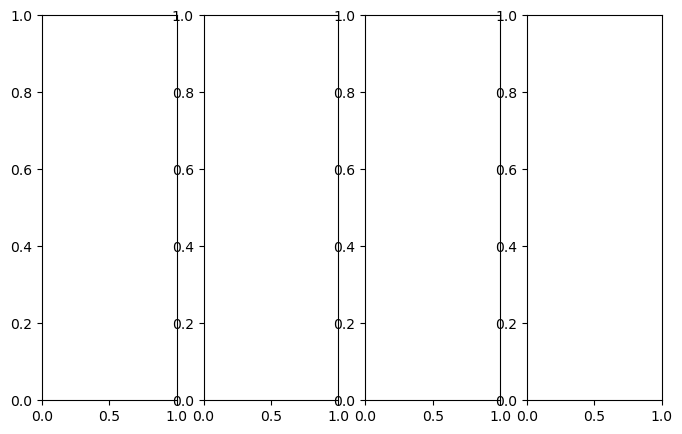

In [7]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(8, 5))

cruises = ['2025-Jan-Pilot', '2025-April', '2025-Summer', '2025-November', '2025-December']
cruise_names = ['January', 'April', 'August', 'November', 'December']
colors = [cruise_colors[c][1] for c in cruises]

max_depth = 100
plot_four = "N2"  # or "chl"


for cruise, cruise_label, color in zip(cruises, cruise_names, colors):
    plot_cruise_median_profiles(
        ax1, ax2, ax3, ax4,
        cruise,
        max_depth,
        color=color,
        label=cruise_label,
        plot_four=plot_four
    )

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_ylim(5, max_depth)
    ax.invert_yaxis()

ax1.set_ylabel('Pressure (dbar)')
ax1.set_xlabel('Conservative Temperature\n(°C)')
ax1.set_yticks([10, 20, 30, 40,50, 60, 70, 80, 90, 100])
ax1.set_xlim(15, 30)

ax2.set_xlabel('Absolute Salinity\n(g/kg)')
ax2.set_yticks([])
ax2.set_xlim(34, 36.5)

ax3.set_xlabel('Potential Density\n(kg/m$^3$)')
ax3.set_yticks([])
ax3.set_xlim(21, 28)

if plot_four == "chl":
    ax4.set_xlabel("Chlorophyll-a\n(mg m$^{-3}$)")
    ax4.set_xlim(0, 1.5)
else:
    ax4.set_xlabel("N$^2$\n(s$^{-2}$)")
    ax4.set_xlim(0, 0.002)
    ax4.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

# ax1.legend(frameon=False)

fig.suptitle("Cruise-wide Median Profiles Across All Transects")
plt.tight_layout()
plt.show()

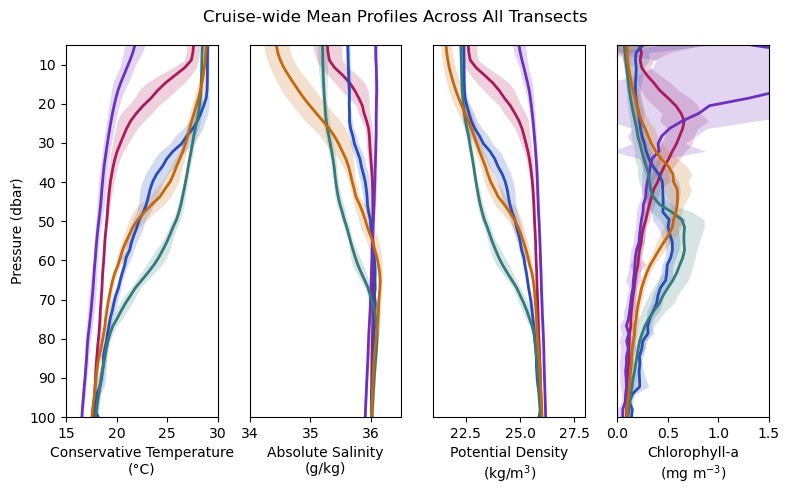

In [ ]:
ax2.set_xlim(34, 36.5)
ax1.set_yticks([10, 20, 30, 40,50, 60, 70, 80, 90, 100])
fig.suptitle("Cruise-wide Mean Profiles Across All Transects")
fig

### (6) plot profiles of for any variables at specified location

In [ ]:
variable_metadata = {
    "CT": {
        "dataset": "ctd",
        "label": r"Temperature ($\degree$C)",
        "units": "°C",
        "xlim": (15, 30),
        "color": "blue"
    },
    "SA": {
        "dataset": "ctd",
        "label": "Salinity (g/kg)",
        "units": "g/kg",
        "xlim": (34.5, 36.5),
        "color": "red"
    },
    "rho": {
        "dataset": "ctd",
        "label": r"Density (kg/m$^3$)",
        "units": "kg/m³",
        "xlim": (21, 28),
        "color": "purple"
    },
    "O2": {
        "dataset": "oxy",
        "label": "Oxygen (mmol/m$^3$)",
        "units": "µmol/kg",
        "xlim": (100, 800), # (100, 250)
        "color": "orange"
    },
    "chl_cal": {
        "dataset": "fls",
        "label": "Chlorophyll (µg/L)",
        "units": "mg/m³",
        "xlim": (0, 2),
        "color": "green"
    },
    "bb470_cal": {
        "dataset": "fls",
        "label": "470nm Backscatter (1/m)",
        "units": "1/m",
        "xlim": (0, 0.0006),
        "color": "brown"
    },
    "bb700_cal": {
        "dataset": "fls",
        "label": "700nm Backscatter (1/m)",
        "units": "1/m",
        "xlim": (0, 0.0006),
        "color": "teal"
    }
}

In [ ]:
def plot_profiles(datasets, show_mean=True):
    max_depth = 150
    depth_grid = np.linspace(10, max_depth, 50)

    # Prepare arrays for interpolation
    CT_interp = np.full((len(datasets), len(depth_grid)), np.nan)
    SA_interp = np.full((len(datasets), len(depth_grid)), np.nan)
    sigma_interp = np.full((len(datasets), len(depth_grid)), np.nan)

    for i, ds in enumerate(datasets):
        p = ds["P"].values
        ct = ds["CT"].values
        sa = ds["SA"].values
        
        # Interpolate missing values
        p = interpolate_nans(p, np.arange(len(p)))
        ct = interpolate_nans(ct, np.arange(len(ct)))
        sa = interpolate_nans(sa, np.arange(len(sa)))
        
        # Interpolate to the common depth grid
        CT_interp[i, :] = np.interp(depth_grid, p, ct, left=np.nan, right=np.nan)
        SA_interp[i, :] = np.interp(depth_grid, p, sa, left=np.nan, right=np.nan)
        sigma_interp[i, :] = gsw.density.sigma0(SA_interp[i, :], CT_interp[i, :])

    # Compute mean and std
    CT_mean = np.nanmean(CT_interp, axis=0)
    CT_std  = np.nanstd(CT_interp, axis=0)

    SA_mean = np.nanmean(SA_interp, axis=0)
    SA_std  = np.nanstd(SA_interp, axis=0)

    sigma_mean = np.nanmean(sigma_interp, axis=0)
    sigma_std  = np.nanstd(sigma_interp, axis=0)

    # Plotting
    fig, axs = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

    if show_mean:
        axs[0].plot(CT_mean, depth_grid, label='CT mean', color='tab:blue')
        axs[0].fill_betweenx(depth_grid, CT_mean - CT_std, CT_mean + CT_std, color='tab:blue', alpha=0.3)
        
        axs[1].plot(SA_mean, depth_grid, label='SA mean', color='tab:green')
        axs[1].fill_betweenx(depth_grid, SA_mean - SA_std, SA_mean + SA_std, color='tab:green', alpha=0.3)

        axs[2].plot(sigma_mean, depth_grid, label='Sigma0 mean', color='tab:red')
        axs[2].fill_betweenx(depth_grid, sigma_mean - sigma_std, sigma_mean + sigma_std, color='tab:red', alpha=0.3)
    else:
        for i in range(len(datasets)):
            axs[0].plot(CT_interp[i, :], depth_grid, color='tab:blue', alpha=0.5)
            axs[1].plot(SA_interp[i, :], depth_grid, color='tab:green', alpha=0.5)
            axs[2].plot(sigma_interp[i, :], depth_grid, color='tab:red', alpha=0.5)

    for ax, title in zip(axs, ['Conservative Temperature (°C)', 'Absolute Salinity (g/kg)', 'Sigma₀ (kg/m³)']):
        ax.invert_yaxis()
        ax.set_xlabel(title)
        ax.grid(True)

    axs[0].set_ylabel('Depth (m)')
    plt.tight_layout()
    plt.show()



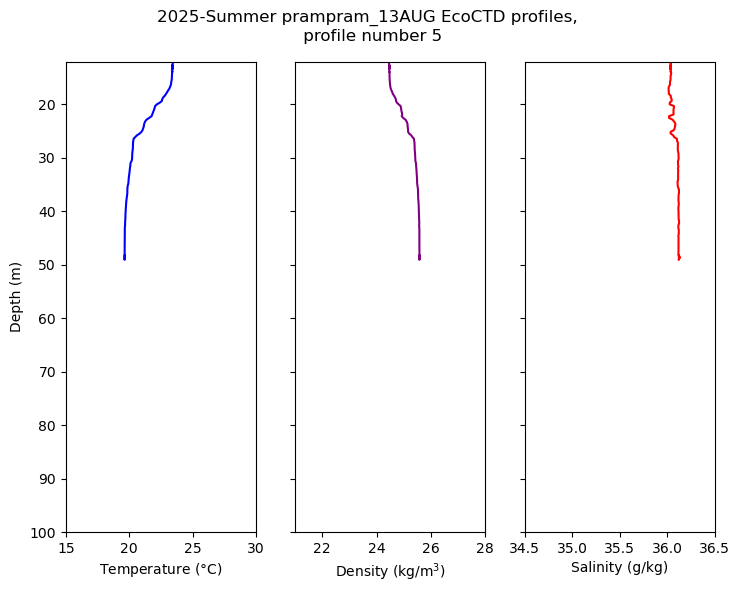

In [ ]:
variables_to_plot = ["CT", "rho", "SA"] 
# OPTIONS: "CT", "rho", "chl_cal", "bb470_cal", "bb700_cal", "O2", "SA"

# Define working directory and transect name
transect_name = 'prampram_13AUG'
cruise = '2025-Summer'
wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"

include_distance = False

# Initialize datasets dictionary
datasets = {}

# load datasets for each data type
for data_type in set(meta["dataset"] for meta in variable_metadata.values()):
    files = glob.glob(f"{wkdir}*{data_type}.nc")
    datasets[data_type] = [xr.open_dataset(f) for f in files]

if transect_name == 'Sakumono' and cruise == '2025-Jan-Pilot':
    for data_type in datasets:
        datasets[data_type] = datasets[data_type][::-1]


max_depth = 100

# determine number of variables
num_vars = len(variables_to_plot)

# create subplots
fig, axes = plt.subplots(1, num_vars, figsize=(2.5 * num_vars, 6))

# ensure axes is iterable
if num_vars == 1:
    axes = [axes]
    plural = ""
else:
    plural = "s"

# set profile index
index = 4

# initialize depth variable
p = None

# plot each variable
for i, var in enumerate(variables_to_plot):
    meta = variable_metadata[var]
    data_type = meta["dataset"]
    ds = datasets[data_type][index]
    ax = axes[i]

    # retrieve/compute variable data
    if var == "rho":
        p = ds["P"].values
        p = interpolate_nans(p, np.arange(len(p)))
        ct = ds["CT"].values
        sa = ds["SA"].values
        ct = interpolate_nans(ct, np.arange(len(ct)))
        sa = interpolate_nans(sa, np.arange(len(sa)))
        data = gsw.density.sigma0(sa, ct)
    else:
        data = ds[var].values
        p = ds["P"].values
        p = interpolate_nans(p, np.arange(len(p)))
        data = interpolate_nans(data, np.arange(len(data)))
        if var == "O2":
            data = data*1000

    # plot data
    ax.plot(data, p, color=meta["color"], linewidth=1.5)
    ax.set_xlabel(meta["label"])
    ax.set_xlim(meta["xlim"])

    # set y-axis label for the first subplot
    if i == 0:
        ax.set_ylabel("Depth (m)")
    else:
        ax.set_yticklabels([])

    ax.set_ylim(12, max_depth)
    ax.invert_yaxis()

if include_distance:
    title = f"{cruise} {transect_name} EcoCTD profile{plural}, \n {round(distance[index], 2)} km offshore"
else:
    title = f"{cruise} {transect_name} EcoCTD profile{plural}, \n profile number {index+1}"
fig.suptitle(title)

plt.tight_layout()
plt.show()



In [ ]:
variables_to_plot = ["CT", "SA", "rho", "chl_cal", "bb470_cal", "bb700_cal", "O2"] 
# OPTIONS: "CT", "rho", "chl_cal", "bb470_cal", "bb700_cal", "O2", "SA"

# Define working directory and transect name
transect_name = 'jamestown' # shakedown_day1, ...day2
cruise = '2025-Summer'
wkdir = f"{os.environ['OMIPATH']}/Coastal Measurements/{cruise}/EcoCTD/data/{transect_name}/Level2/"

# Initialize datasets dictionary
datasets = {}

# load datasets for each data type
for data_type in set(meta["dataset"] for meta in variable_metadata.values()):
    files = glob.glob(f"{wkdir}*{data_type}.nc")
    datasets[data_type] = [xr.open_dataset(f) for f in files]

if transect_name == 'Sakumono' and cruise == '2025-Jan-Pilot':
    for data_type in datasets:
        datasets[data_type] = datasets[data_type][::-1]


max_depth = 100

# determine number of variables
num_vars = len(variables_to_plot)

# create subplots
fig, axes = plt.subplots(1, num_vars, figsize=(2.5 * num_vars, 6))

# ensure axes is iterable
if num_vars == 1:
    axes = [axes]
    plural = ""
else:
    plural = "s"

# set profile indices
indices = np.arange(7)

depth_grid = np.linspace(10, max_depth, 50)

# plot each variable
for i, var in enumerate(variables_to_plot):

    data_interp = np.full((len(indices), len(depth_grid)), np.nan)

    for index in indices:

        meta = variable_metadata[var]
        data_type = meta["dataset"]
        ds = datasets[data_type][index]
        ax = axes[i]

        # retrieve/compute variable data
        if var == "rho":
            p = ds["P"].values
            p = interpolate_nans(p, np.arange(len(p)))
            ct = ds["CT"].values
            sa = ds["SA"].values
            ct = interpolate_nans(ct, np.arange(len(ct)))
            sa = interpolate_nans(sa, np.arange(len(sa)))
            # data = gsw.density.sigma0(sa, ct)

            # Interpolate to the common depth grid
            CT_interp = np.interp(depth_grid, p, ct, left=np.nan, right=np.nan)
            SA_interp = np.interp(depth_grid, p, sa, left=np.nan, right=np.nan)
            data_interp[index, :] = gsw.density.sigma0(SA_interp, CT_interp)
        else:
            data = ds[var].values
            p = ds["P"].values
            p = interpolate_nans(p, np.arange(len(p)))
            data = interpolate_nans(data, np.arange(len(data)))
            
            if var == "O2":
                data = data*1000
                
            data_interp[index, :] = np.interp(depth_grid, p, data, left=np.nan, right=np.nan)

    data_mean = np.nanmean(data_interp, axis=0)
    data_std  = np.nanstd(data_interp, axis=0)

    ax.plot(data_mean, depth_grid, color=meta["color"], linewidth=2, label="Mean")
    ax.fill_betweenx(depth_grid, data_mean - data_std, data_mean + data_std, color=meta["color"], alpha=0.2, linewidth=0)

    ax.set_xlabel(meta["label"])
    ax.set_xlim(meta["xlim"])

    # set y-axis label for the first subplot
    if i == 0:
        ax.set_ylabel("Depth (m)")
    else:
        ax.set_yticklabels([])

    ax.set_ylim(12, max_depth)
    ax.invert_yaxis()

title = f"{cruise} {transect_name} Average EcoCTD profile{plural}"
fig.suptitle(title)

plt.tight_layout()
plt.show()


/home/jvynn/anaconda3/envs/lab/lib/python3.12/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


KeyboardInterrupt: 